# Create LLM Evaluation Figure

In [197]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from hiatus.config import metrics, metrics_dir, plots_dir, tables_dir

In [198]:
plots_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

In [199]:
mpl.rcParams.update({
	"lines.linewidth": 2.0,
	"xtick.labelsize": 20,
	"ytick.labelsize": 20,
	"axes.labelsize": 20,
	"legend.fontsize": 20,
	"axes.titlesize": 20,
	"font.family": "sans-serif",
	"pdf.fonttype": 42,
	"ps.fonttype": 42,
	"figure.labelsize": 20,
	"text.usetex": False,
})

In [200]:
from collections import OrderedDict
import re


def load_results(paths, sense_scores=True) -> pd.DataFrame:
    results = pd.DataFrame()
    for path in paths:
        if sense_scores:
            data = pd.read_json(path, lines=True)
        else:
            data = pd.read_csv(path)

        results = pd.concat([results, data])
    return results


def get_genre(path: str) -> str:
    stem = Path(path).stem
    return stem.split("_promptremix")[0]


def resolve_glob_templates(glob_templates, style):
    paths = []
    for base_dir, subdir, pattern_template in glob_templates:
        base_path = Path(base_dir, subdir)
        if not base_path.exists():
            continue

        pattern = pattern_template.format(style=style)
        paths.extend(p.as_posix() for p in base_path.glob(pattern))

    return sorted(set(paths))


def build_metrics_path_from_config(config, alpha_by_style):
    metrics_path = OrderedDict()

    for group_key, group_cfg in config.items():
        for style in group_cfg["styles"]:
            sense_scores = resolve_glob_templates(group_cfg["sense_glob_templates"], style)
            privacy_scores = resolve_glob_templates(group_cfg["privacy_glob_templates"], style)

            entry_key = f"{group_key}_s{style}"
            metrics_path[entry_key] = {
                "language": group_cfg["language"],
                "n_styles_to_change": style,
                "sense_scores": sense_scores,
                "privacy_consistency": privacy_scores,
                "color": (group_cfg["color_base"], alpha_by_style[style]),
                "label": group_cfg.get("label", group_cfg["xtick_label"]),
                "xtick_label": group_cfg["xtick_label"],
                "experiment_id": group_cfg["experiment_id"],
                "report": bool(sense_scores) or bool(privacy_scores),
            }

    return metrics_path


def build_per_genre_mean_metrics_df(metrics_path, columns):
    rows = []

    for model_name, cfg in metrics_path.items():
        if not cfg["report"]:
            continue

        experiment_id = str(cfg["experiment_id"])
        for file_path in cfg["sense_scores"]:
            results = load_results([file_path])
            results = results.drop(columns="documentID", errors="ignore")

            available_cols = [col for col in columns if col in results.columns]
            if not available_cols:
                continue
            results = results[available_cols]

            for col in available_cols:
                if col in metrics:
                    results[col] = results[col] * metrics[col]["scale"]

            row = results.mean(axis=0).to_dict()
            row["language"] = cfg["language"]
            row["genre"] = get_genre(file_path)
            row["n_styles_to_change"] = cfg["n_styles_to_change"]
            row["model_label"] = cfg["label"]
            row["experiment_id"] = experiment_id
            rows.append(row)

    group_cols = ["language", "genre", "experiment_id", "model_label", "n_styles_to_change"]
    if not rows:
        return pd.DataFrame(columns=group_cols + columns)

    df = pd.DataFrame(rows)
    metric_cols = [col for col in columns if col in df.columns]
    df = df.groupby(group_cols, as_index=False)[metric_cols].mean()

    for col in columns:
        if col not in df.columns:
            df[col] = np.nan

    return df[group_cols + columns]


def build_per_genre_privacy_df(metrics_path, metric_name="delta_equal_error_rate"):
    rows = []

    for model_name, cfg in metrics_path.items():
        if not cfg["report"]:
            continue

        experiment_id = str(cfg["experiment_id"])
        for file_path in cfg["privacy_consistency"]:
            results = load_results([file_path], sense_scores=False)
            if results.empty:
                continue

            metric_value = float(results.iloc[:, :1].mean(axis=0).iloc[0])
            rows.append(
                {
                    "language": cfg["language"],
                    "genre": get_genre(file_path),
                    "n_styles_to_change": cfg["n_styles_to_change"],
                    "model_label": cfg["label"],
                    "experiment_id": experiment_id,
                    metric_name: metric_value,
                }
            )

    group_cols = ["language", "genre", "experiment_id", "model_label", "n_styles_to_change"]
    if not rows:
        return pd.DataFrame(columns=group_cols + [metric_name])

    df = pd.DataFrame(rows)
    df = df.groupby(group_cols, as_index=False)[metric_name].mean()
    return df


def filter_plot_df(df: pd.DataFrame) -> pd.DataFrame:
    df_plot = df.copy()
    if "language" not in df_plot.columns or "genre" not in df_plot.columns:
        return df_plot

    if "en" in df_plot["language"].unique():
        df_plot = df_plot[
            ~((df_plot["language"] == "en") & (df_plot["genre"].str.contains("HRS2", na=False)))
        ]

    return df_plot


def build_per_genre_layout(df_lang, metrics_path, lang, width=0.2, intra_group_gap=0.08, genre_gap=0.55):
    method_order = []
    method_labels = {}
    style_lookup = {}

    for model_name, cfg in metrics_path.items():
        if not cfg["report"] or cfg["language"] != lang:
            continue

        experiment_id = str(cfg["experiment_id"])
        if experiment_id not in method_order:
            method_order.append(experiment_id)

        method_labels.setdefault(experiment_id, cfg.get("xtick_label", cfg["label"]))
        style_lookup[(experiment_id, cfg["n_styles_to_change"])] = {
            "color": cfg["color"],
        }

    ordered_rows = []
    x_positions = []
    colors = []
    style_labels = []
    tick_positions = []
    tick_labels = []
    genre_centers = OrderedDict()
    genre_boundaries = []

    cursor = 0.0
    genres = sorted(df_lang["genre"].unique())

    for genre_idx, genre in enumerate(genres):
        genre_x = []

        available_methods = []
        for experiment_id in method_order:
            method_df = df_lang[
                (df_lang["genre"] == genre)
                & (df_lang["experiment_id"] == experiment_id)
            ]
            if not method_df.empty:
                available_methods.append(experiment_id)

        for method_idx, experiment_id in enumerate(available_methods):
            method_df = df_lang[
                (df_lang["genre"] == genre)
                & (df_lang["experiment_id"] == experiment_id)
            ].sort_values("n_styles_to_change")

            experiment_x = []
            experiment_styles = []

            for _, row in method_df.iterrows():
                style = int(row["n_styles_to_change"])
                style_cfg = style_lookup.get(
                    (experiment_id, style),
                    {"color": ("#777777", 0.9)},
                )

                ordered_rows.append(row.to_dict())
                x_positions.append(cursor)
                colors.append(style_cfg["color"])
                style_labels.append(str(style))

                genre_x.append(cursor)
                experiment_x.append(cursor)
                experiment_styles.append(style)
                cursor += width

            if experiment_x:
                if 2 in experiment_styles:
                    style2_idx = experiment_styles.index(2)
                    tick_x = experiment_x[style2_idx]
                else:
                    tick_x = float(np.mean(experiment_x))

                tick_positions.append(tick_x)
                tick_labels.append(method_labels.get(experiment_id, experiment_id))

            if method_idx < len(available_methods) - 1:
                cursor += intra_group_gap

        if genre_x:
            genre_centers[genre] = float(np.mean(genre_x))

        if genre_idx < len(genres) - 1:
            genre_boundaries.append(cursor + genre_gap / 2.0)
            cursor += genre_gap

    ordered_df = pd.DataFrame(ordered_rows)

    return {
        "ordered_df": ordered_df,
        "x": np.array(x_positions),
        "width": width,
        "colors": colors,
        "style_labels": style_labels,
        "tick_positions": tick_positions,
        "tick_labels": tick_labels,
        "genre_centers": genre_centers,
        "genre_boundaries": genre_boundaries,
    }


def prettify_title(metric_key):
    if metric_key == "delta_equal_error_rate":
        return "Delta Equal Error Rate (↑)"
    if metric_key in metrics:
        return metrics[metric_key]["title"]
    return metric_key

In [201]:
use_old_ar_model = True
ar_sense_code = "ar_old_model" if use_old_ar_model else "ar"
baseline_metrics_dir = Path("/gscratch/ifml1/hiatus/metrics/")

# Explicit plotting config: add/remove entries here for manual control.
# You can also change xtick_label per metric group.
PLOT_GROUP_CONFIG = OrderedDict(
    {
        "zh_baseline": {
            "language": "zh",
            "experiment_id": "baseline",
            "xtick_label": "Baseline",
            "color_base": "#027100",
            "styles": [1, 2, 3],
            "sense_glob_templates": [
                (baseline_metrics_dir, "zh", "*{style}_llm.jsonl"),
            ],
            "privacy_glob_templates": [
                (baseline_metrics_dir, "zh", "*{style}_ta3_results.csv"),
            ],
        },
        "zh_qwen35": {
            "language": "zh",
            "experiment_id": "qwen3.5",
            "xtick_label": "Qwen 3.5",
            "color_base": "#027100",
            "styles": [1, 2, 3],
            "sense_glob_templates": [
                (metrics_dir, "zh", "*zh0-qwen3.5-{style}_llm.jsonl"),
            ],
            "privacy_glob_templates": [
                (metrics_dir, "zh", "*zh0-qwen3.5-{style}_ta3_results.csv"),
            ],
        },
        # "zh_constrained": {
        #     "language": "zh",
        #     "experiment_id": "constrained",
        #     "xtick_label": "Constrained",
        #     "color_base": "#027100",
        #     "styles": [1, 2, 3],
        #     "sense_glob_templates": [
        #         (metrics_dir, "zh", "*zh0-qwen3.5-constr-{style}_llm.jsonl"),
        #     ],
        #     "privacy_glob_templates": [
        #         (metrics_dir, "zh", "*zh0-qwen3.5-constr-{style}_ta3_results.csv"),
        #     ],
        # },
        "zh_transfer": {
            "language": "zh",
            "experiment_id": "transfer",
            "xtick_label": "Transfer",
            "color_base": "#027100",
            "styles": [1, 2, 3],
            "sense_glob_templates": [
                (metrics_dir, "zh", "*zh0-transfer-qwen3_5-{style}_llm.jsonl"),
            ],
            "privacy_glob_templates": [
                (metrics_dir, "zh", "*zh0-transfer-qwen3_5-{style}_ta3_results.csv"),
            ],
        },
        "ar_baseline": {
            "language": "ar",
            "experiment_id": "baseline",
            "xtick_label": "Baseline",
            "color_base": "#DF6800",
            "styles": [1, 2, 3],
            "sense_glob_templates": [
                (baseline_metrics_dir, "ar", "*ar0-{style}_llm.jsonl"),
                # (metrics_dir, ar_sense_code, "*ar22-baseline-{style}_llm.jsonl"),
            ],
            "privacy_glob_templates": [
                (baseline_metrics_dir, "ar", "*ar0-{style}_ta3_results.csv"),
                # (metrics_dir, "ar", "*ar22-baseline-{style}_ta3_results.csv"),
            ],
        },
		"ar_qwen25": {
            "language": "ar",
            "experiment_id": "qwen2.5",
            "xtick_label": "Qwen 2.5",
            "color_base": "#DF6800",
            "styles": [1, 2, 3],
            "sense_glob_templates": [
                # (baseline_metrics_dir, "ar", "*{style}_llm.jsonl"),
                (metrics_dir, ar_sense_code, "*ar22-baseline-{style}_llm.jsonl"),
            ],
            "privacy_glob_templates": [
                # (baseline_metrics_dir, "ar", "*{style}_ta3_results.csv"),
                (metrics_dir, "ar", "*ar22-baseline-{style}_ta3_results.csv"),
            ],
        },
        "ar_qwen35": {
            "language": "ar",
            "experiment_id": "qwen3.5",
            "xtick_label": "Qwen 3.5",
            "color_base": "#DF6800",
            "styles": [1, 2, 3],
            "sense_glob_templates": [
                (metrics_dir, ar_sense_code, "*ar22-qwen3.5-{style}_llm.jsonl"),
            ],
            "privacy_glob_templates": [
                (metrics_dir, "ar", "*ar22-qwen3.5-{style}_ta3_results.csv"),
            ],
        },
        # "ar_constrained": {
        #     "language": "ar",
        #     "experiment_id": "constrained",
        #     "xtick_label": "Constrained",
        #     "color_base": "#DF6800",
        #     "styles": [1, 2, 3],
        #     "sense_glob_templates": [
        #         (metrics_dir, ar_sense_code, "*ar22-qwen3.5-constr-{style}_llm.jsonl"),
        #     ],
        #     "privacy_glob_templates": [
        #         (metrics_dir, "ar", "*ar22-qwen3.5-constr-{style}_ta3_results.csv"),
        #     ],
        # },
        "en_baseline": {
            "language": "en",
            "experiment_id": "baseline",
            "xtick_label": "Baseline",
            "color_base": "#004D80",
            "styles": [1, 2, 3],
            "sense_glob_templates": [
                (baseline_metrics_dir, "en", "*{style}_llm.jsonl"),
            ],
            "privacy_glob_templates": [
                (baseline_metrics_dir, "en", "*{style}_ta3_results.csv"),
            ],
        },
        "en_qwen35": {
            "language": "en",
            "experiment_id": "qwen3.5",
            "xtick_label": "Qwen 3.5",
            "color_base": "#004D80",
            "styles": [1, 2, 3],
            "sense_glob_templates": [
                (metrics_dir, "en", "*enF-qwen3.5-{style}_llm.jsonl"),
            ],
            "privacy_glob_templates": [
                (metrics_dir, "en", "*enF-qwen3.5-{style}_ta3_results.csv"),
            ],
        },
        # "en_constrained": {
        #     "language": "en",
        #     "experiment_id": "constrained",
        #     "xtick_label": "Constrained",
        #     "color_base": "#004D80",
        #     "styles": [1, 2, 3],
        #     "sense_glob_templates": [
        #         (metrics_dir, "en", "*enF-qwen3.5-constr-{style}_llm.jsonl"),
        #     ],
        #     "privacy_glob_templates": [
        #         (metrics_dir, "en", "*enF-qwen3.5-constr-{style}_ta3_results.csv"),
        #     ],
        # },
        "ru_baseline": {
            "language": "ru",
            "experiment_id": "baseline",
            "xtick_label": "Baseline",
            "color_base": "#800000",
            "styles": [1, 2, 3],
            "sense_glob_templates": [
                (baseline_metrics_dir, "ru", "*{style}_llm.jsonl"),
            ],
            "privacy_glob_templates": [
                (baseline_metrics_dir, "ru", "*{style}_ta3_results.csv"),
            ],
        },
        "ru_qwen35": {
            "language": "ru",
            "experiment_id": "qwen3.5",
            "xtick_label": "Qwen 3.5",
            "color_base": "#800000",
            "styles": [1, 2, 3],
            "sense_glob_templates": [
                (metrics_dir, "ru", "*ru-qwen3.5-{style}_llm.jsonl"),
            ],
            "privacy_glob_templates": [
                (metrics_dir, "ru", "*ru-qwen3.5-{style}_ta3_results.csv"),
            ],
        },
        # "ru_constrained": {
        #     "language": "ru",
        #     "experiment_id": "constrained",
        #     "xtick_label": "Constrained",
        #     "color_base": "#800000",
        #     "styles": [1, 2, 3],
        #     "sense_glob_templates": [
        #         (metrics_dir, "ru", "*ru-qwen3.5-constr-{style}_llm.jsonl"),
        #     ],
        #     "privacy_glob_templates": [
        #         (metrics_dir, "ru", "*ru-qwen3.5-constr-{style}_ta3_results.csv"),
        #     ],
        # },
    }
)

alpha_by_style = {1: 0.2, 2: 0.5, 3: 0.8}
metrics_path = build_metrics_path_from_config(PLOT_GROUP_CONFIG, alpha_by_style)

pd.DataFrame(
    [
        {
            "language": cfg["language"],
            "experiment_id": cfg["experiment_id"],
            "xtick_label": cfg["xtick_label"],
            "style": cfg["n_styles_to_change"],
            "sense_files": len(cfg["sense_scores"]),
            "privacy_files": len(cfg["privacy_consistency"]),
            "report": cfg["report"],
        }
        for cfg in metrics_path.values()
    ]
).sort_values(["language", "experiment_id", "style"])

,language,experiment_id,xtick_label,style,sense_files,privacy_files,report
9,ar,baseline,Baseline,1,2,2,True
10,ar,baseline,Baseline,2,2,2,True
11,ar,baseline,Baseline,3,2,2,True
12,ar,qwen2.5,Qwen 2.5,1,4,4,True
13,ar,qwen2.5,Qwen 2.5,2,4,4,True
14,ar,qwen2.5,Qwen 2.5,3,4,4,True
15,ar,qwen3.5,Qwen 3.5,1,4,4,True
16,ar,qwen3.5,Qwen 3.5,2,4,4,True
17,ar,qwen3.5,Qwen 3.5,3,4,4,True
18,en,baseline,Baseline,1,12,12,True


In [202]:
def format_genre_label(genre):
    label = str(genre)
    label = label.replace("perGenre-", "")
    label = label.replace("_crossGenre", " crossGenre")
    label = label.replace("_", " ")
    label = re.sub(r"\s+", " ", label).strip()
    return label


def plot_per_genre_metric_block(
    df,
    metrics_path,
    metric_cols,
    nrows,
    ncols,
    figsize,
    output_suffix,
    tick_rotation=70,
    width=0.2,
    intra_group_gap=0.08,
    genre_gap=0.55,
):
    df_plot = filter_plot_df(df)
    if df_plot.empty:
        raise ValueError("No data available for plotting.")

    for lang in sorted(df_plot["language"].unique()):
        df_lang = df_plot[df_plot["language"] == lang].copy()
        layout = build_per_genre_layout(
            df_lang=df_lang,
            metrics_path=metrics_path,
            lang=lang,
            width=width,
            intra_group_gap=intra_group_gap,
            genre_gap=genre_gap,
        )

        if layout["ordered_df"].empty:
            continue

        genre_label_rotation = 35 if lang in {"en", "zh"} else 0
        genre_label_y = -0.31 if genre_label_rotation else -0.24
        genre_label_ha = "right" if genre_label_rotation else "center"

        fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey="row", sharex=True)
        axes_flat = np.array(axes).reshape(-1)
        bottom_row_start = max(0, len(axes_flat) - ncols)

        for i, ax in enumerate(axes_flat):
            if i >= len(metric_cols):
                ax.axis("off")
                continue

            metric = metric_cols[i]
            if metric in layout["ordered_df"].columns:
                metric_series = layout["ordered_df"][metric]
            else:
                metric_series = pd.Series(np.nan, index=layout["ordered_df"].index)

            valid_mask = metric_series.notna().to_numpy()
            x_values = layout["x"][valid_mask]
            y_values = metric_series[valid_mask].to_numpy()
            color_values = [c for c, keep in zip(layout["colors"], valid_mask) if keep]
            bar_labels = [s for s, keep in zip(layout["style_labels"], valid_mask) if keep]

            bars = ax.bar(
                x_values,
                y_values,
                width=layout["width"],
                color=color_values,
                edgecolor="black",
                linewidth=1.0,
                zorder=2,
            )

            if len(bars) > 0:
                ax.bar_label(bars, bar_labels, padding=0, fontsize=8)

            ax.set_title(prettify_title(metric))
            ax.set_ylim(0, 1.05)
            ax.set_xticks(layout["tick_positions"])
            ax.set_xticklabels(
                layout["tick_labels"],
                rotation=tick_rotation,
                ha="right",
                color="grey",
                fontsize=9,
            )
            ax.grid(axis="y", which="major", color="gray", alpha=0.35, linestyle="-", linewidth=0.8)
            ax.set_axisbelow(True)

            if nrows > 1 and i < bottom_row_start:
                ax.tick_params(axis="x", labelbottom=False)

            for boundary in layout["genre_boundaries"]:
                ax.axvline(boundary, color="lightgray", linestyle="-", linewidth=0.7, alpha=0.5)

            if i >= bottom_row_start:
                for genre, center in layout["genre_centers"].items():
                    ax.text(
                        center,
                        genre_label_y,
                        format_genre_label(genre),
                        transform=ax.get_xaxis_transform(),
                        ha=genre_label_ha,
                        va="top",
                        rotation=genre_label_rotation,
                        rotation_mode="anchor",
                        fontsize=9,
                        fontweight="bold",
                    )

        fig.suptitle(f"{lang.upper()} Per-Genre Method Comparison", y=1.01)
        plt.subplots_adjust(wspace=0.08, hspace=0.35, bottom=0.35, top=0.9)

        path = Path(plots_dir, f"prompt-remix-{lang}-{output_suffix}.pdf")
        path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(path.as_posix(), bbox_inches="tight")
        plt.show()

In [203]:
# Legacy helper cell intentionally left blank.
# Filename-style parsing is no longer required because datasets are configured explicitly in PLOT_GROUP_CONFIG.

In [204]:
# Legacy helper cell intentionally left blank.
# Metrics path now comes from build_metrics_path_from_config(PLOT_GROUP_CONFIG, alpha_by_style).

## Sense Scores

In [205]:
columns = list(metrics.keys())[:6]
df = build_per_genre_mean_metrics_df(metrics_path, columns)

In [206]:
df_plot = filter_plot_df(df)
(
    df_plot.groupby(["language", "experiment_id"])["genre"]
    .nunique()
    .unstack(fill_value=0)
)

experiment_id,baseline,qwen2.5,qwen3.5,transfer
language,,,,
ar,2,4,4,0
en,7,0,7,0
ru,6,0,6,0
zh,7,0,7,7


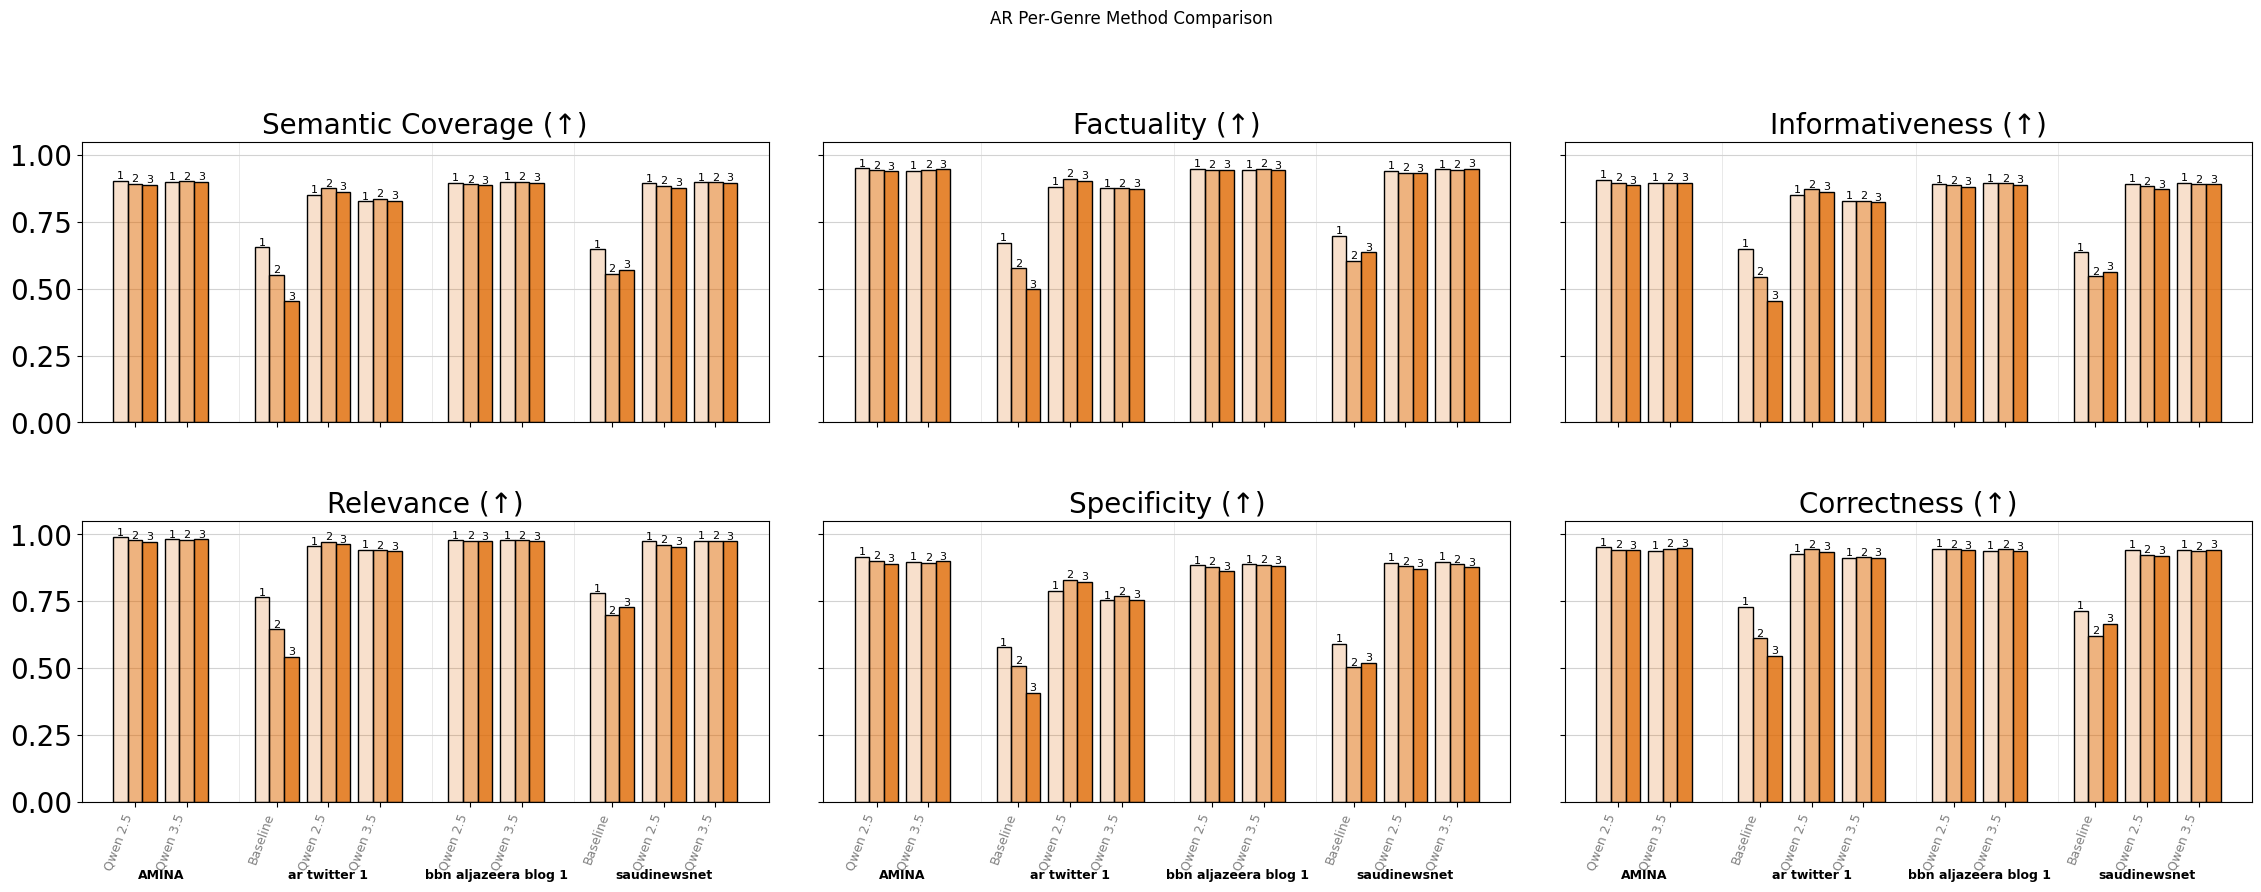

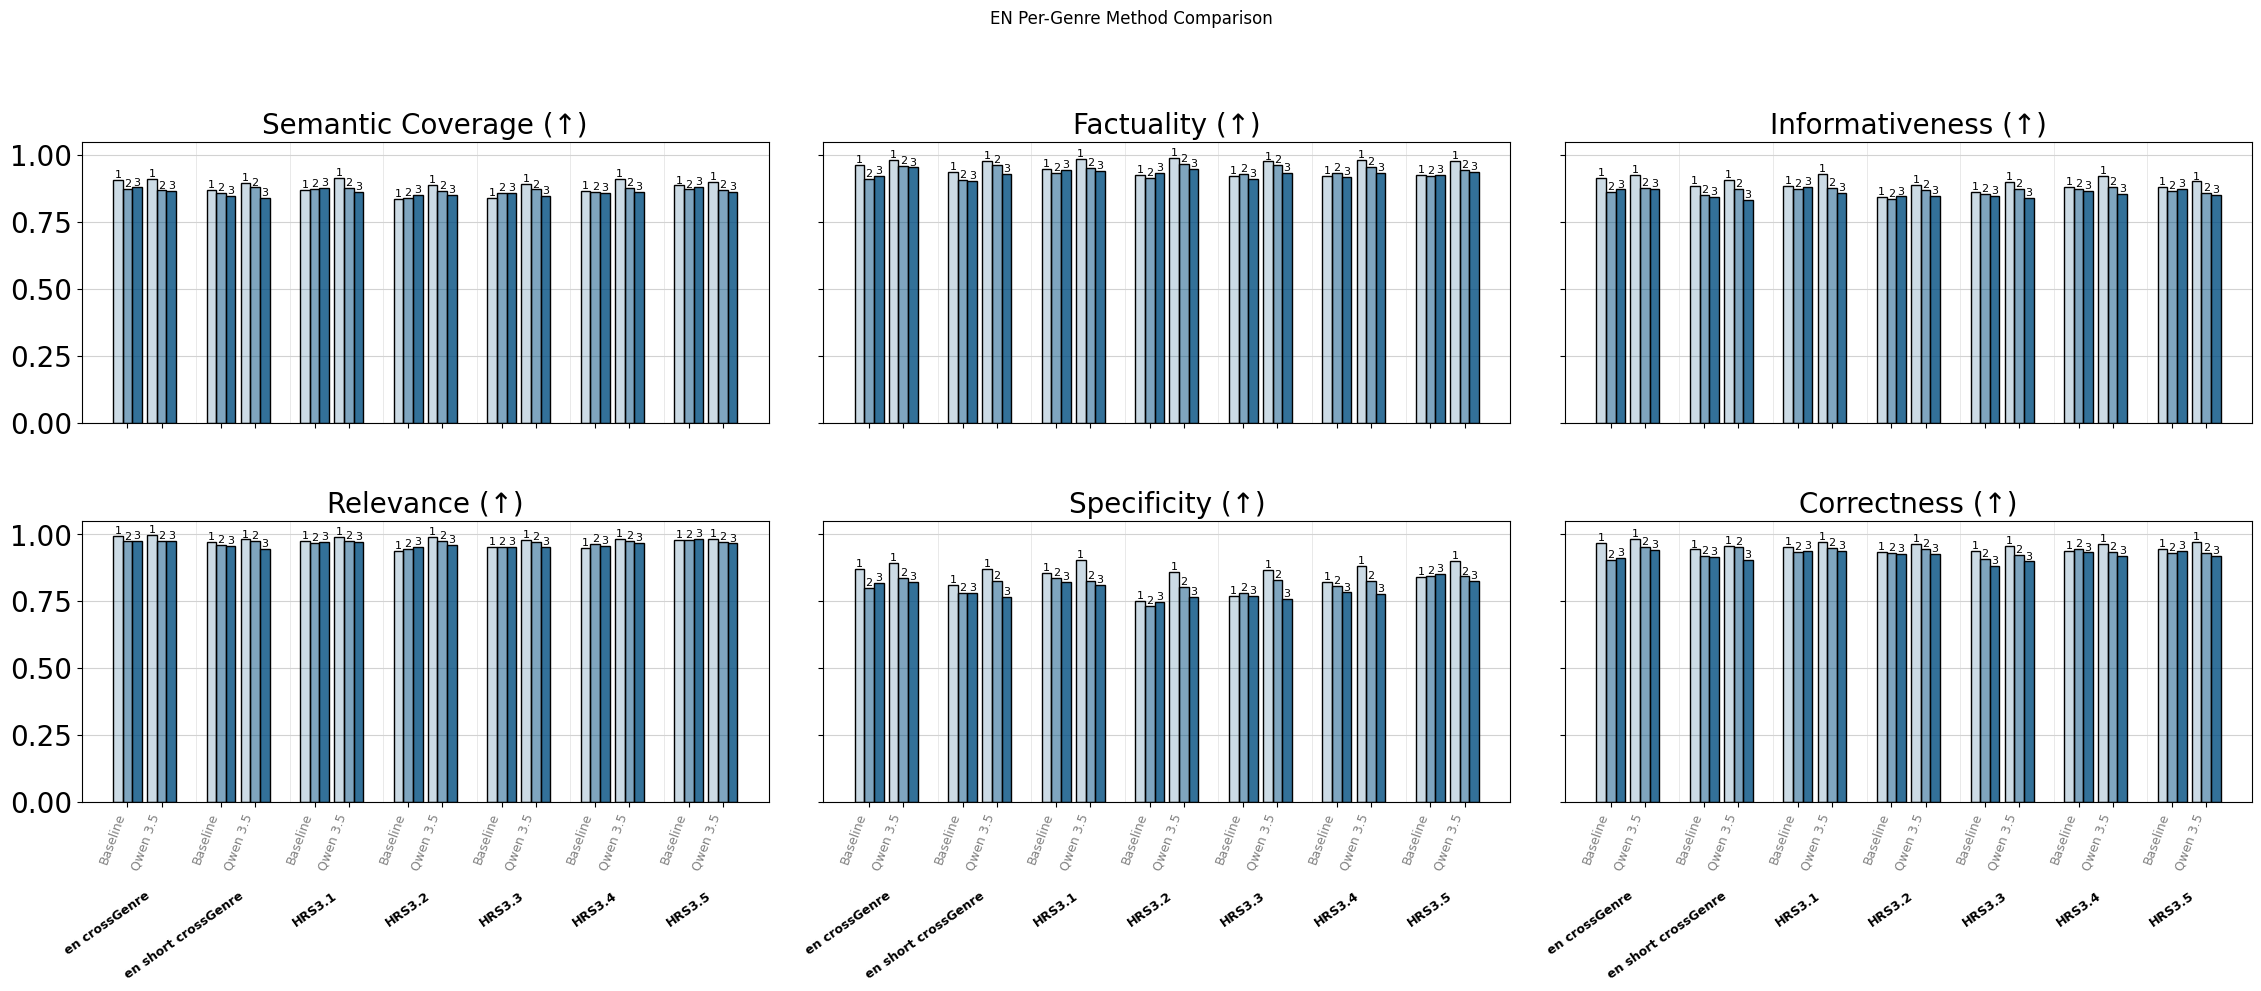

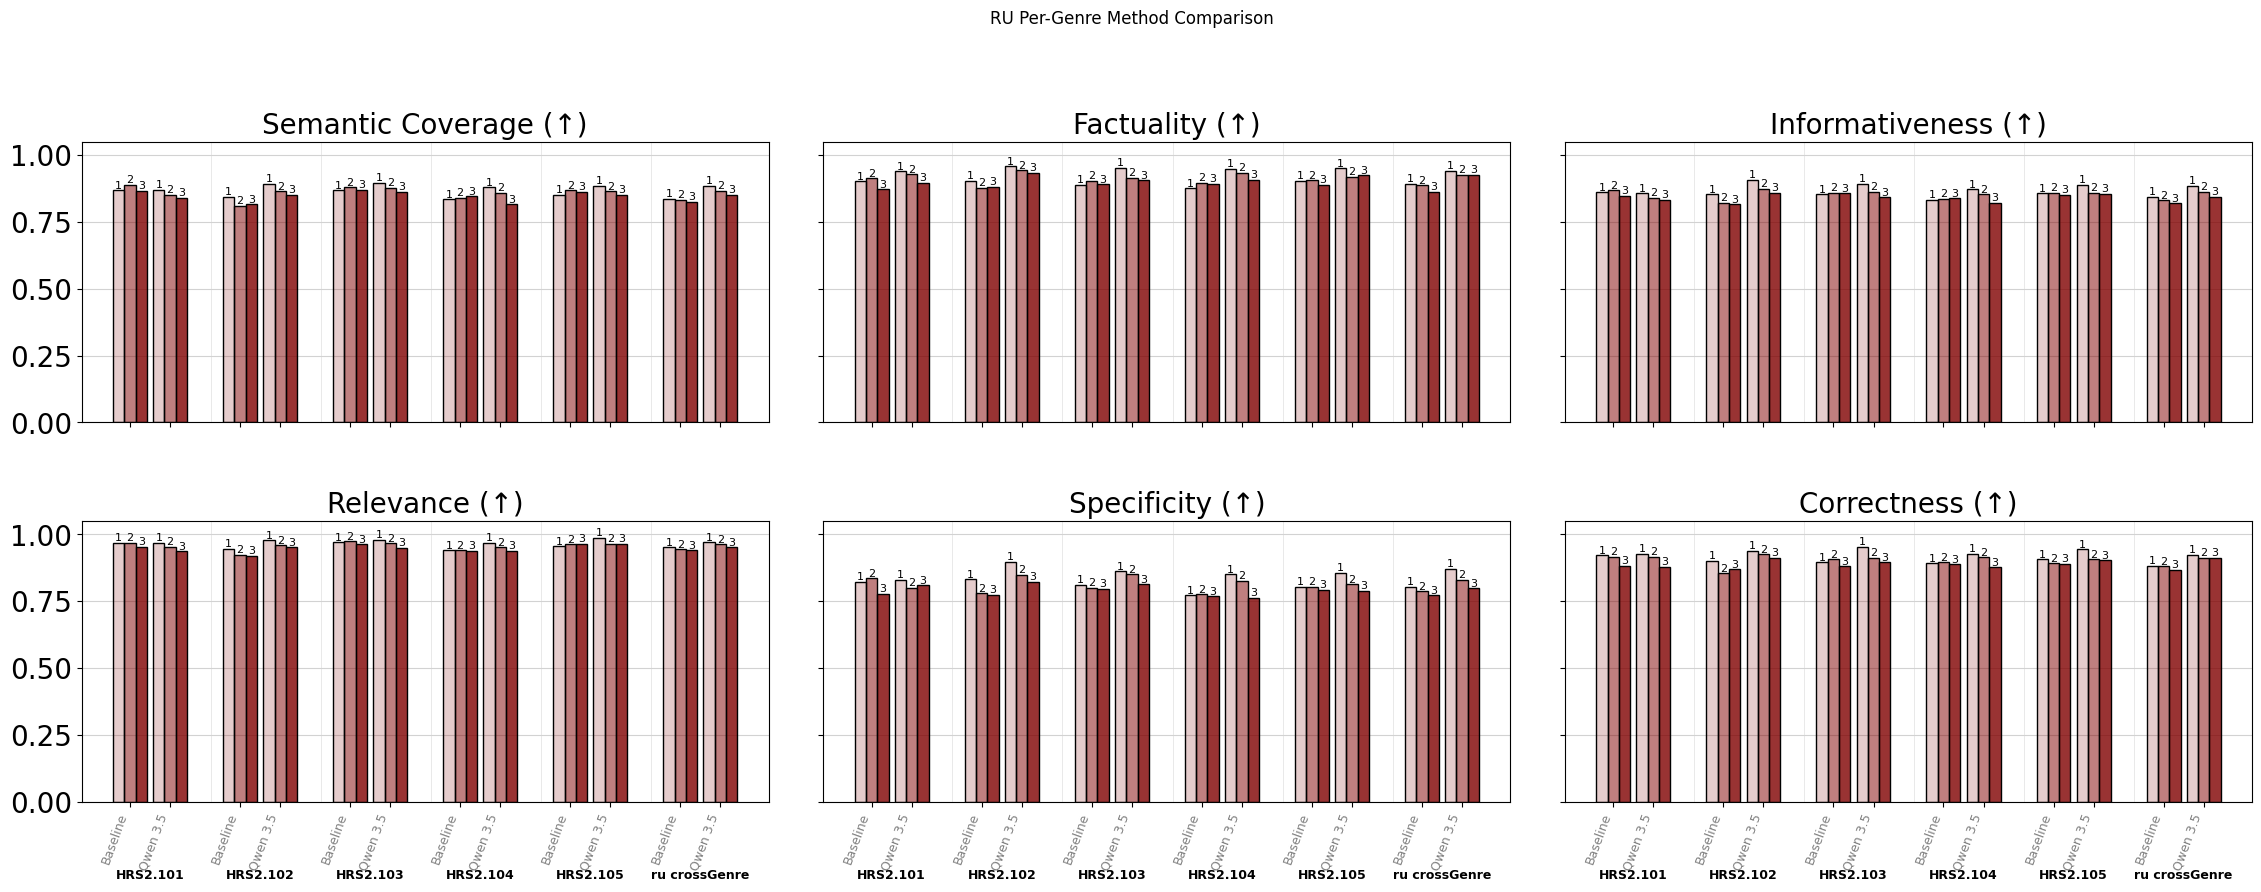

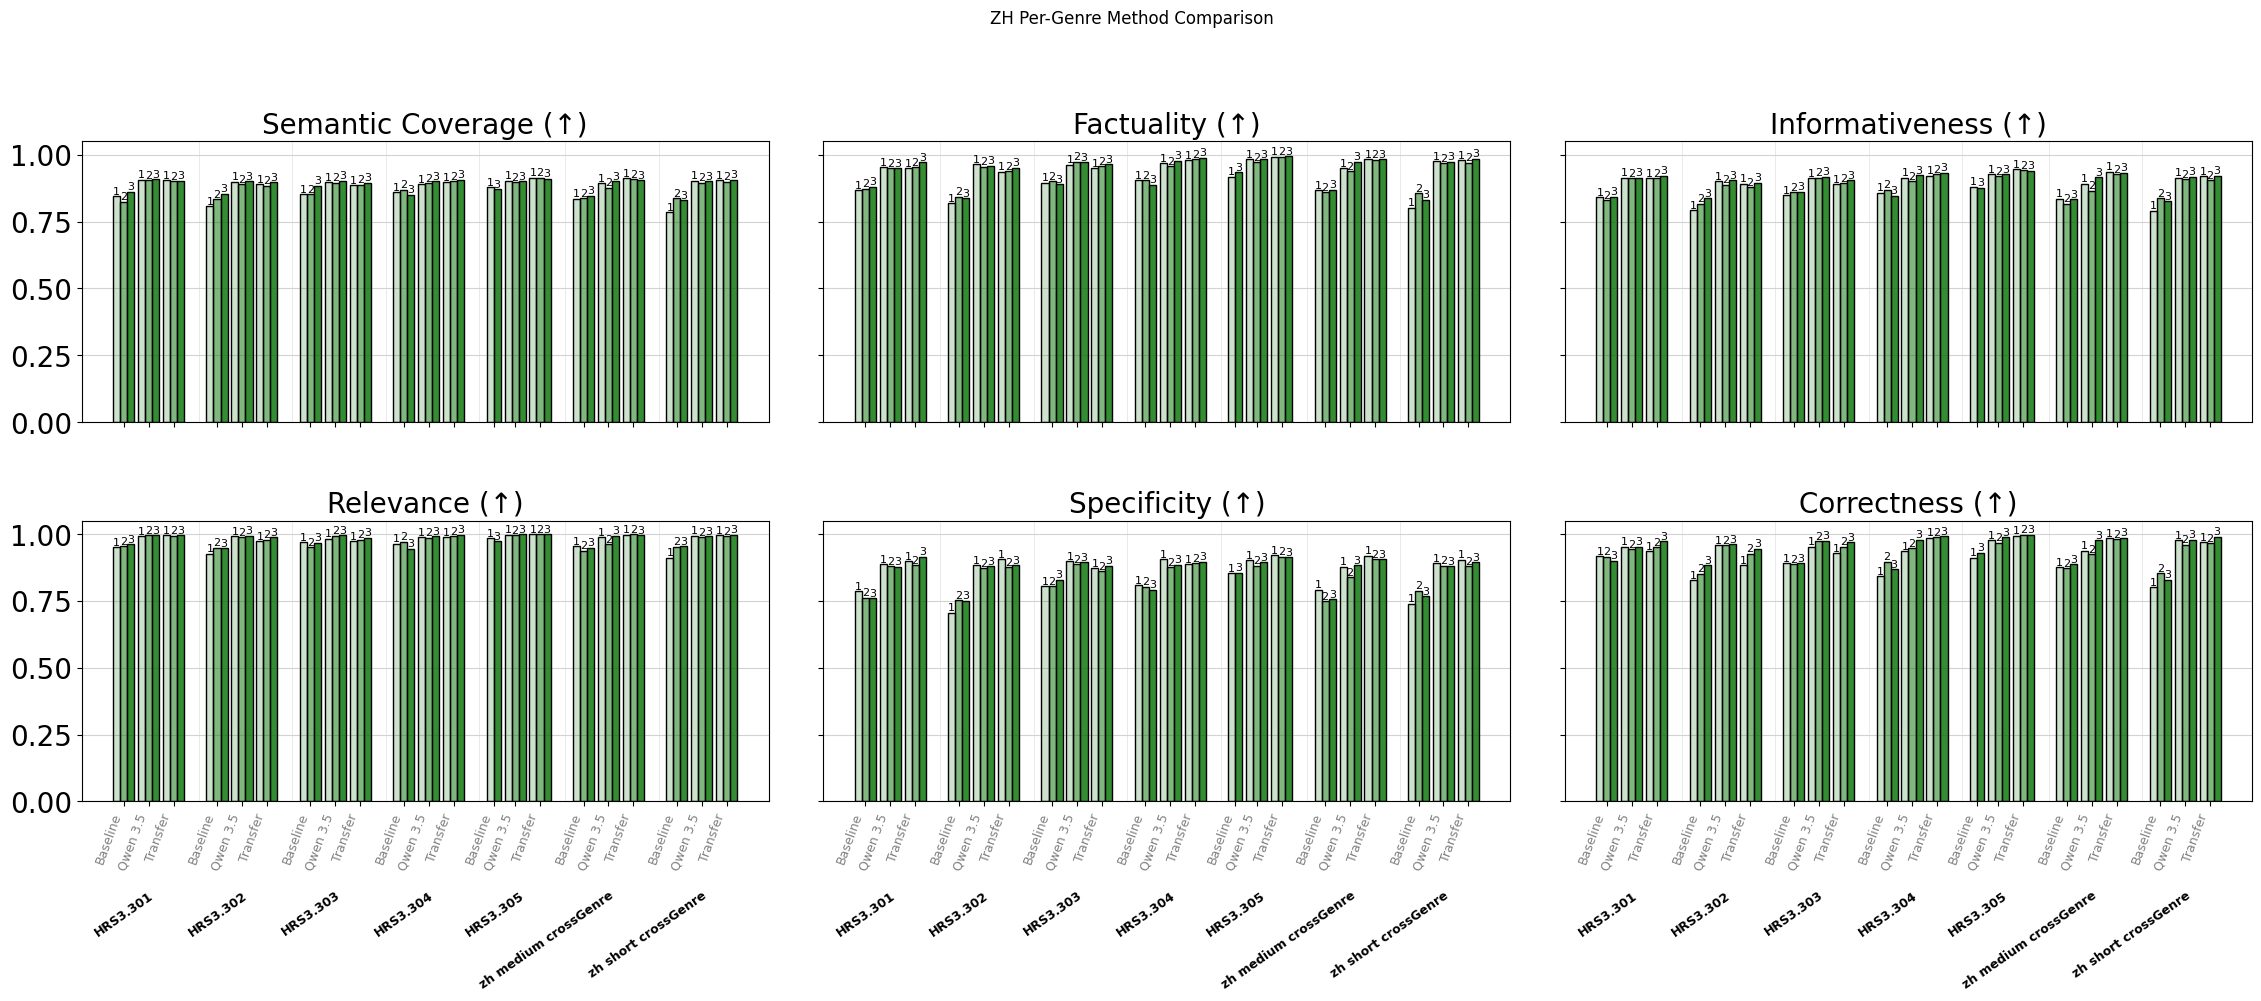

In [207]:
plot_per_genre_metric_block(
    df=df_plot,
    metrics_path=metrics_path,
    metric_cols=columns,
    nrows=2,
    ncols=3,
    figsize=(28, 12),
    output_suffix="per-genre-methods-1",
    tick_rotation=70,
    width=0.22,
    intra_group_gap=0.12,
    genre_gap=0.7,
)

In [208]:
columns = list(metrics.keys())[6:12]
df = build_per_genre_mean_metrics_df(metrics_path, columns)

In [209]:
df_plot = filter_plot_df(df)
(
    df_plot.groupby(["language", "experiment_id"])["genre"]
    .nunique()
    .unstack(fill_value=0)
)

experiment_id,baseline,qwen2.5,qwen3.5,transfer
language,,,,
ar,2,4,4,0
en,7,0,7,0
ru,6,0,6,0
zh,7,0,7,7


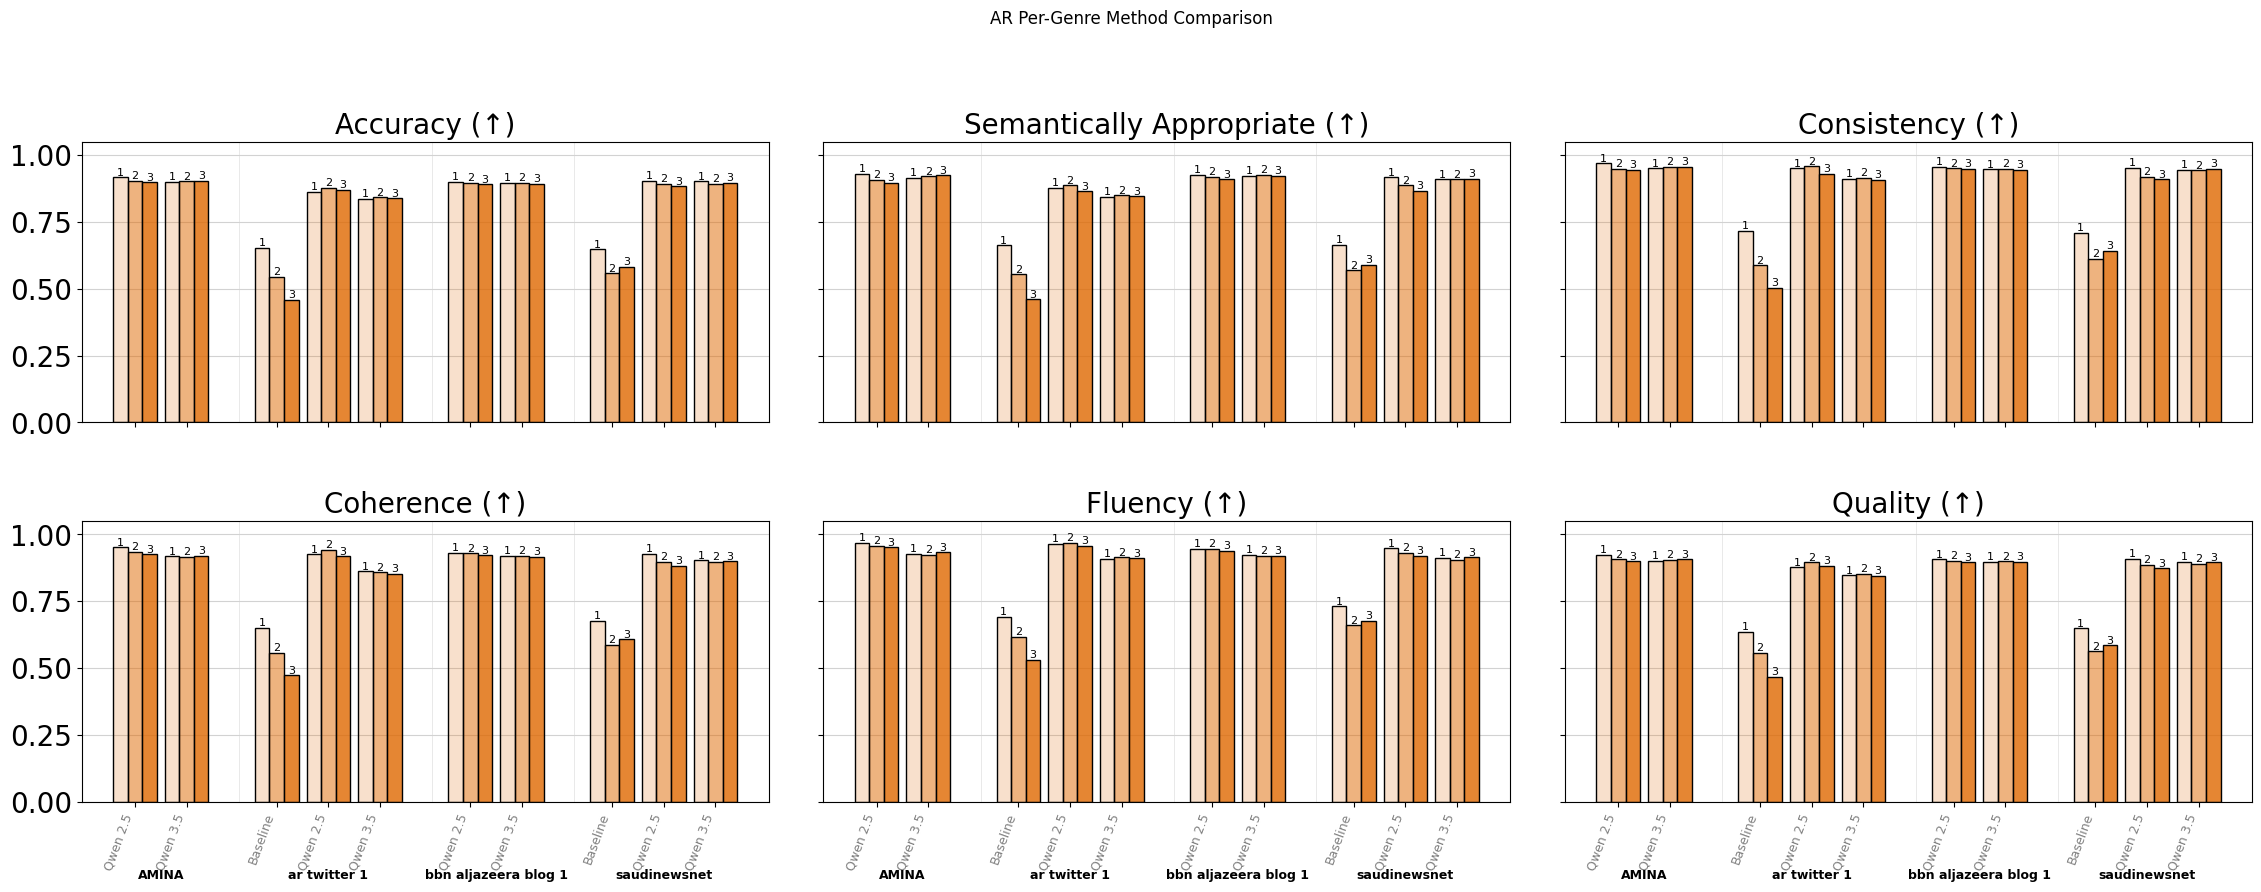

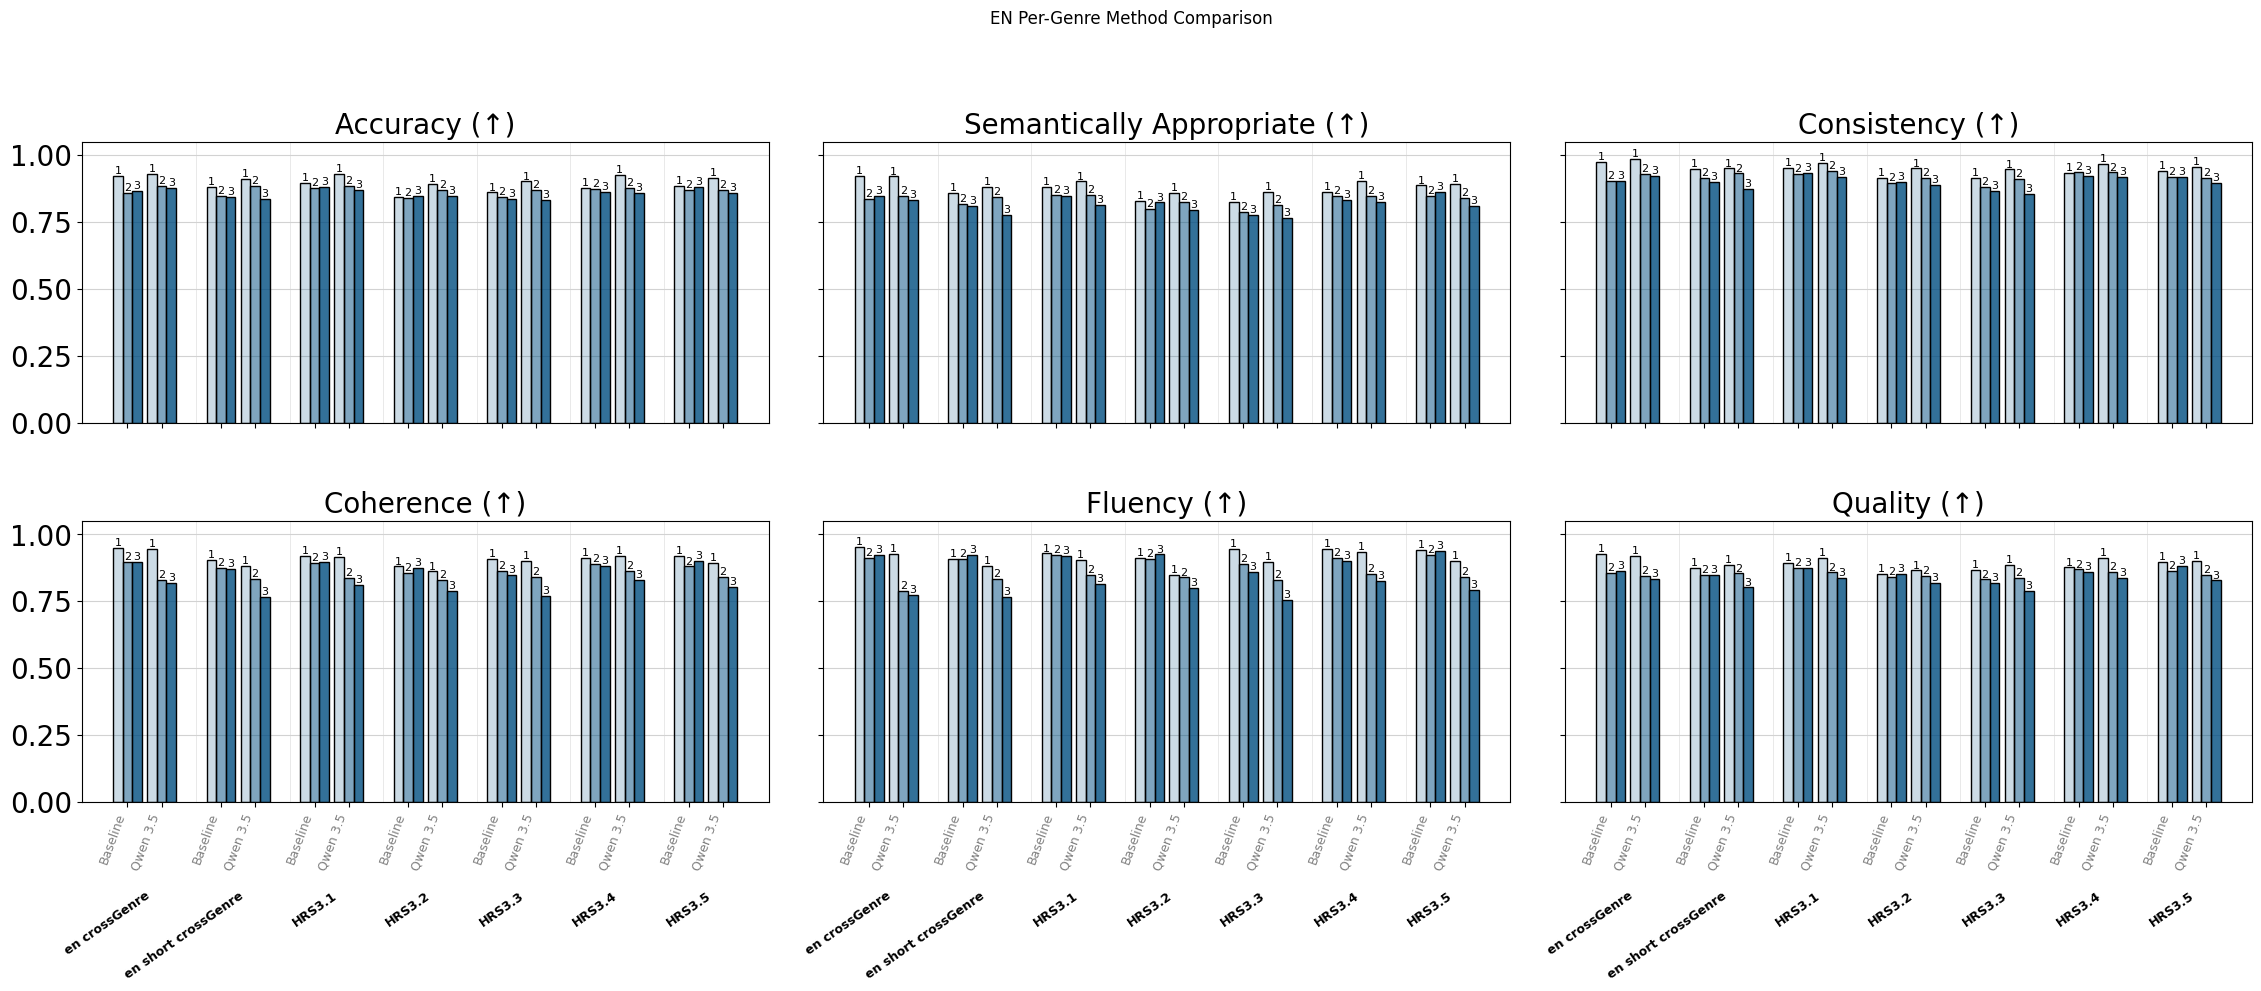

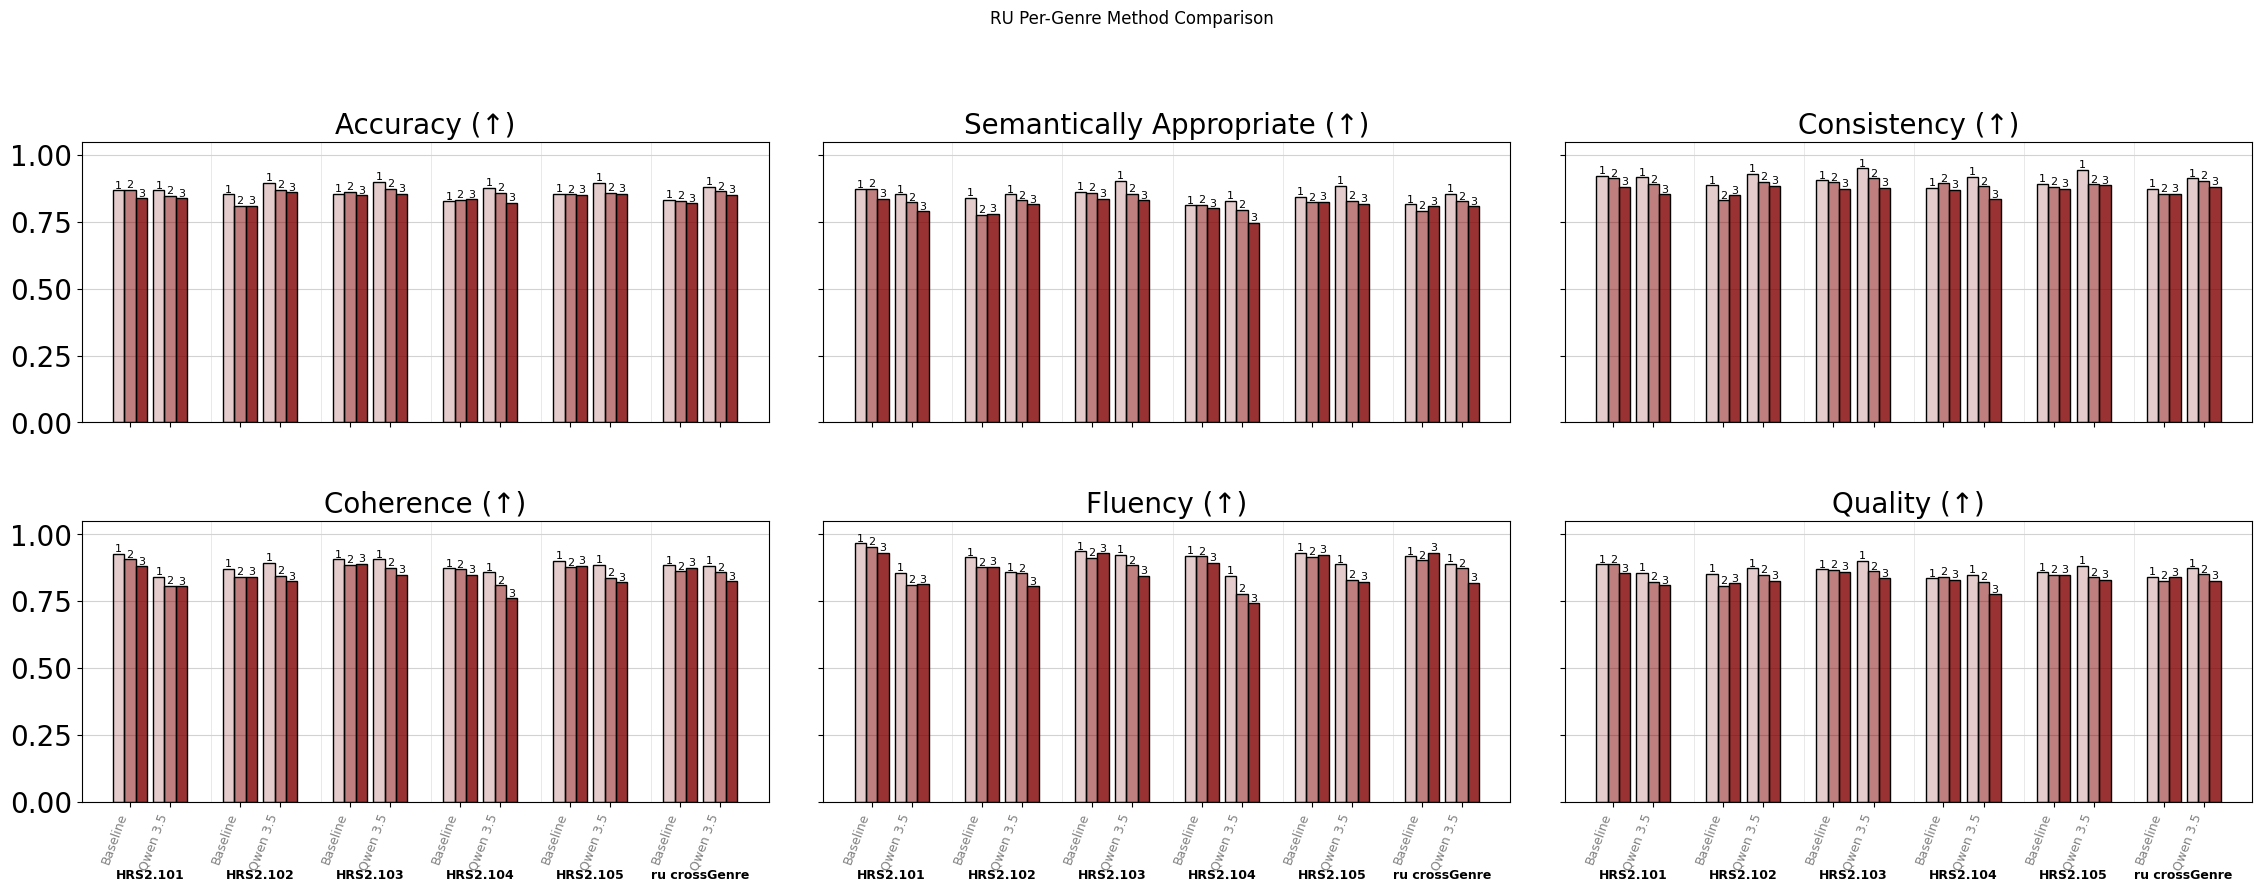

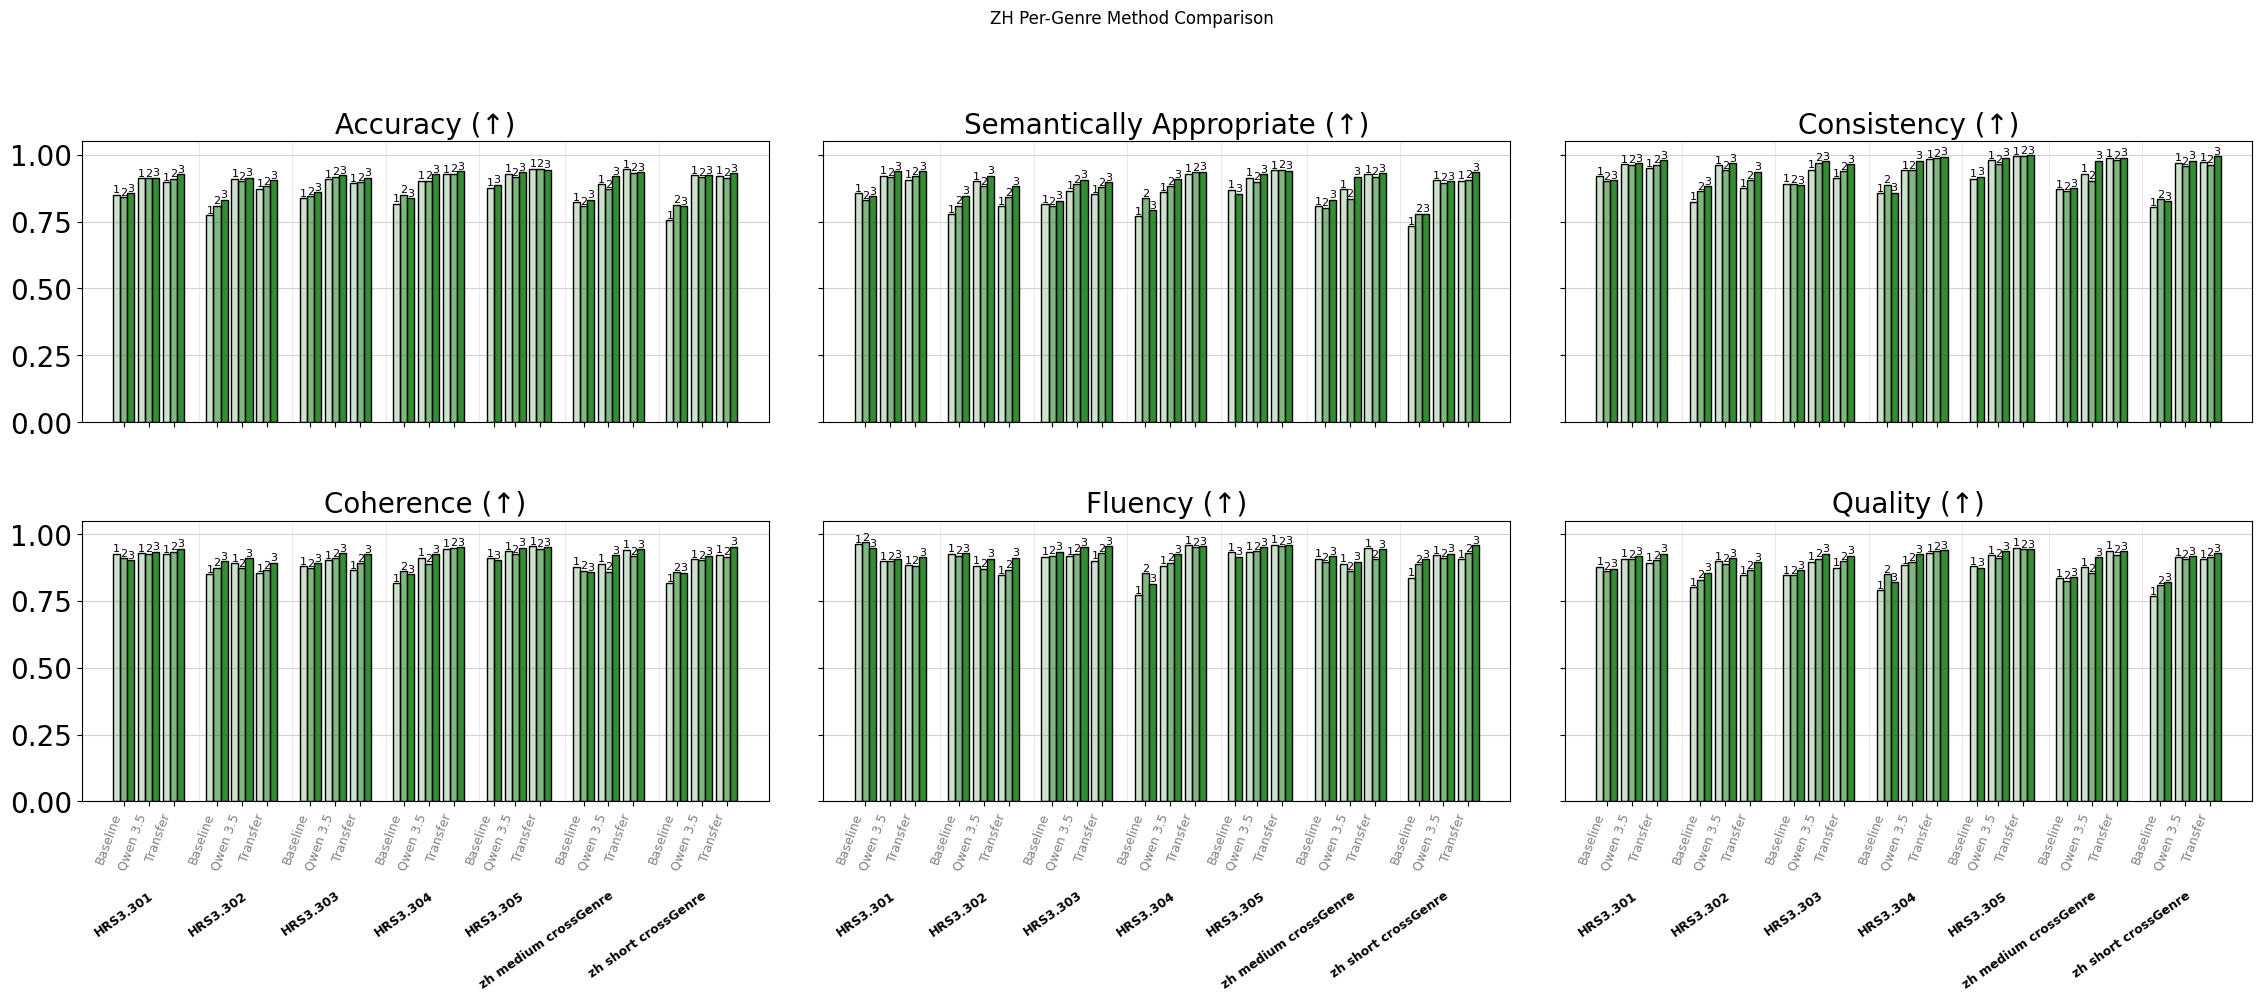

In [210]:
plot_per_genre_metric_block(
    df=df_plot,
    metrics_path=metrics_path,
    metric_cols=columns,
    nrows=2,
    ncols=3,
    figsize=(28, 12),
    output_suffix="per-genre-methods-2",
    tick_rotation=70,
    width=0.22,
    intra_group_gap=0.12,
    genre_gap=0.7,
)

In [211]:
# Spacer cell between metric sections.

## Privacy + Remaining Sense Scores

In [212]:
df_priv = build_per_genre_privacy_df(metrics_path, metric_name="delta_equal_error_rate")

In [213]:
columns_sense = list(metrics.keys())[12:14]
df_sense = build_per_genre_mean_metrics_df(metrics_path, columns_sense)

merge_keys = ["language", "genre", "experiment_id", "model_label", "n_styles_to_change"]
df_merged = df_sense.merge(df_priv, on=merge_keys, how="outer")

In [214]:
metric_cols = ["delta_equal_error_rate"] + columns_sense

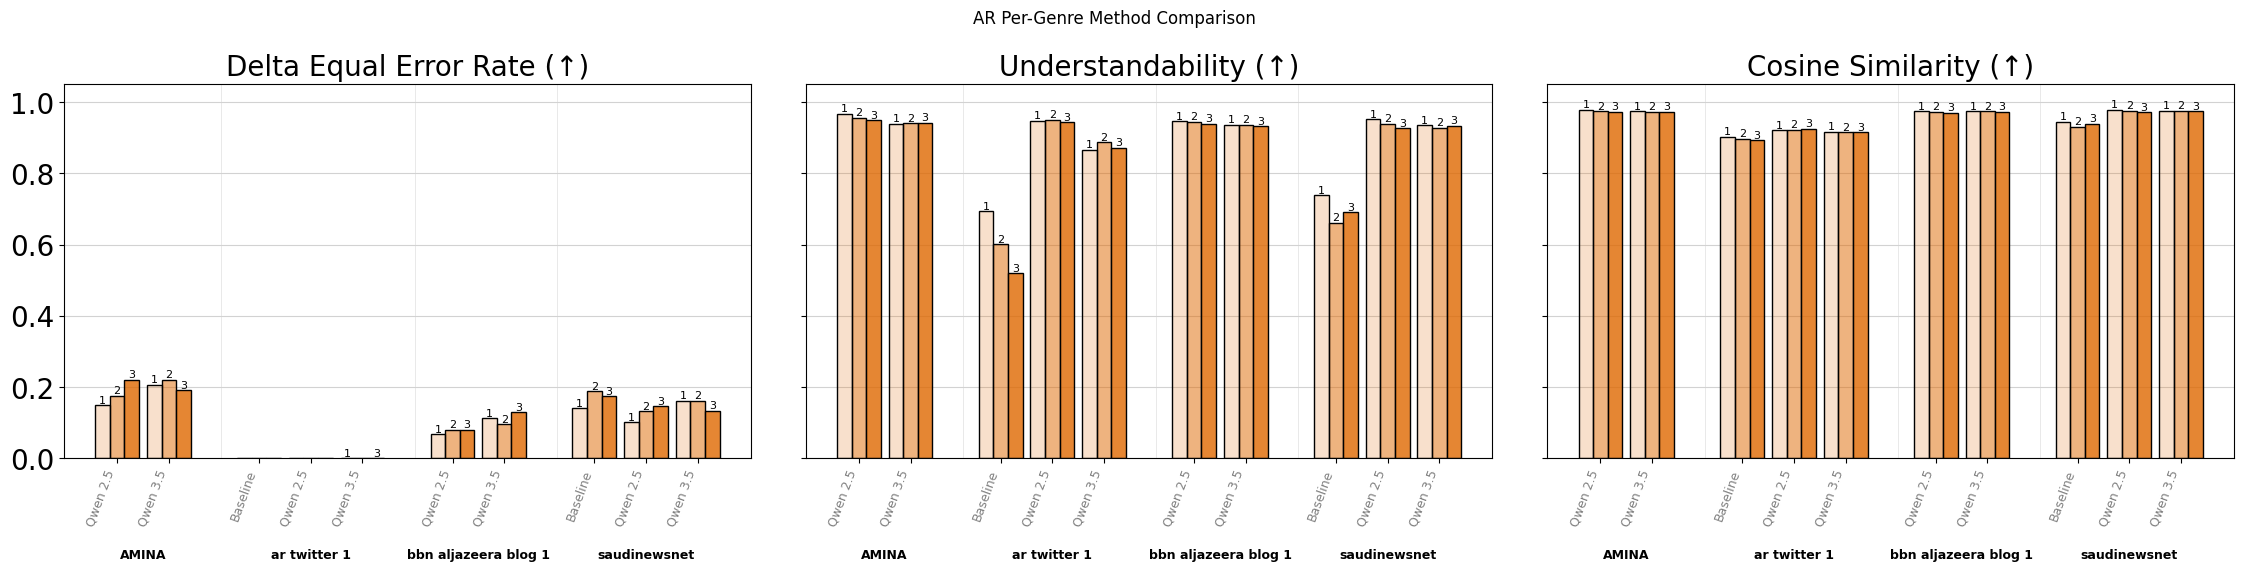

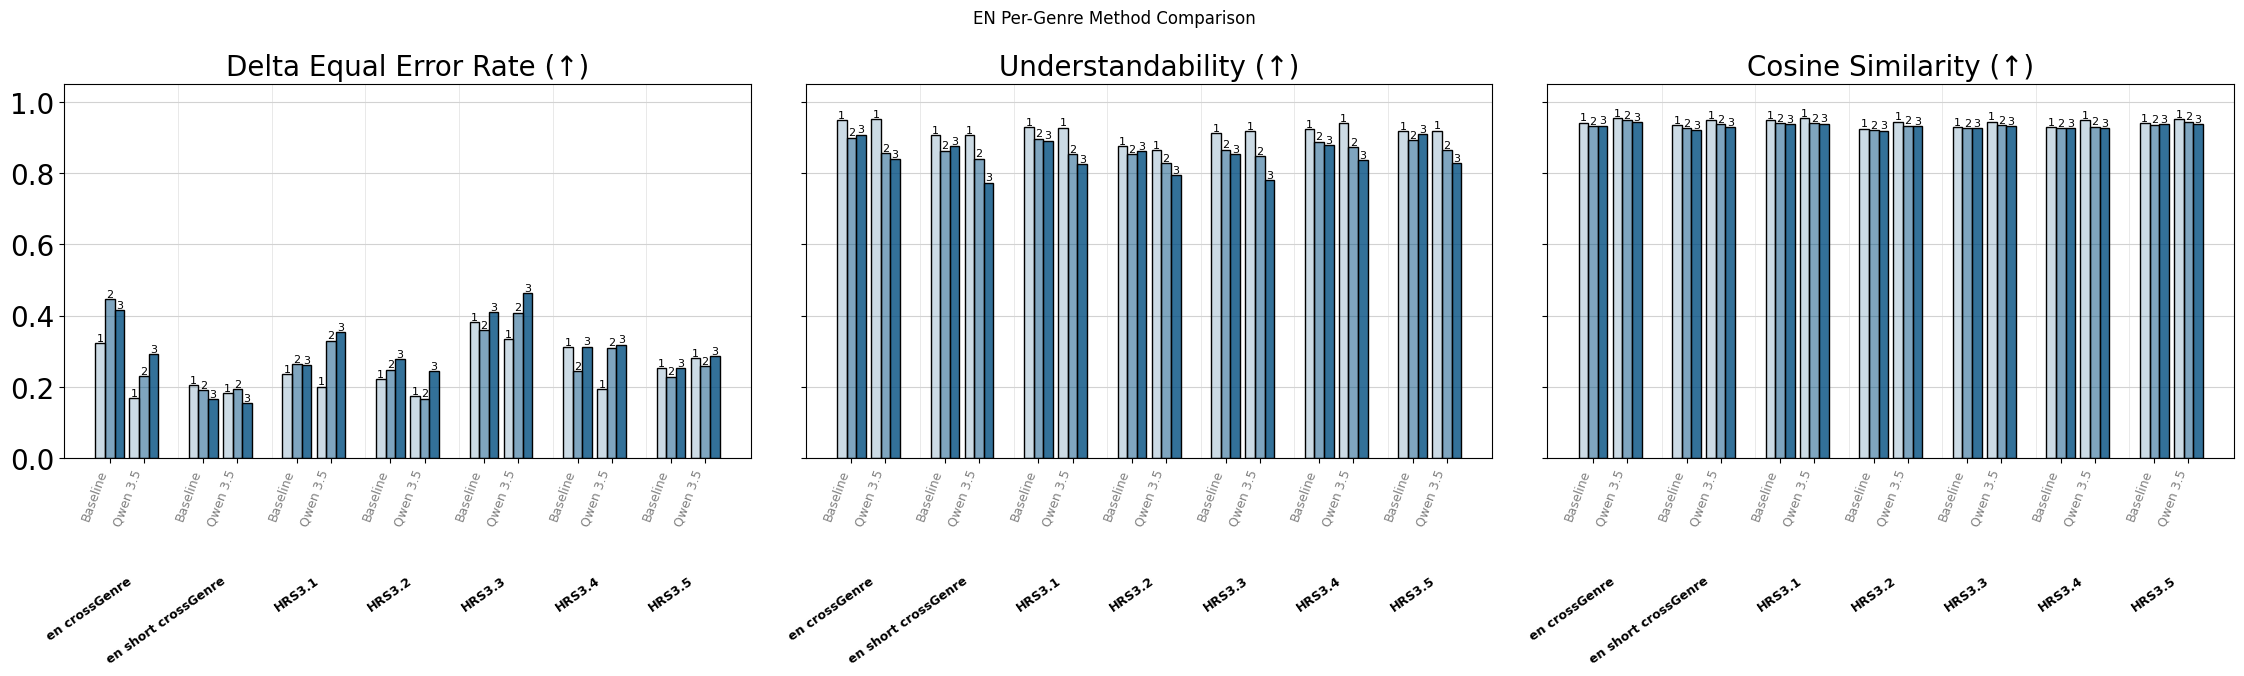

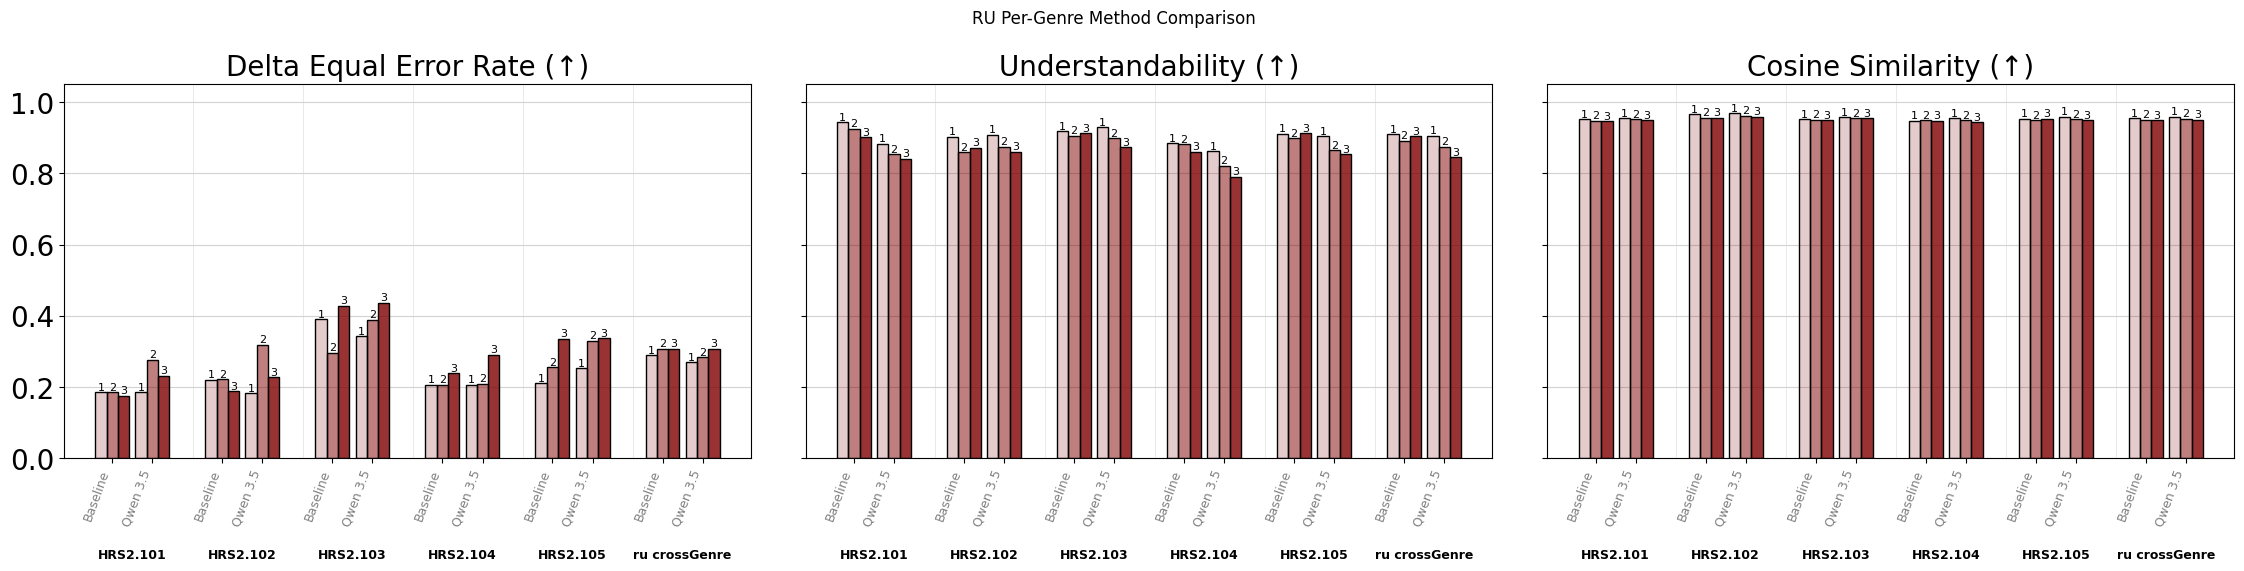

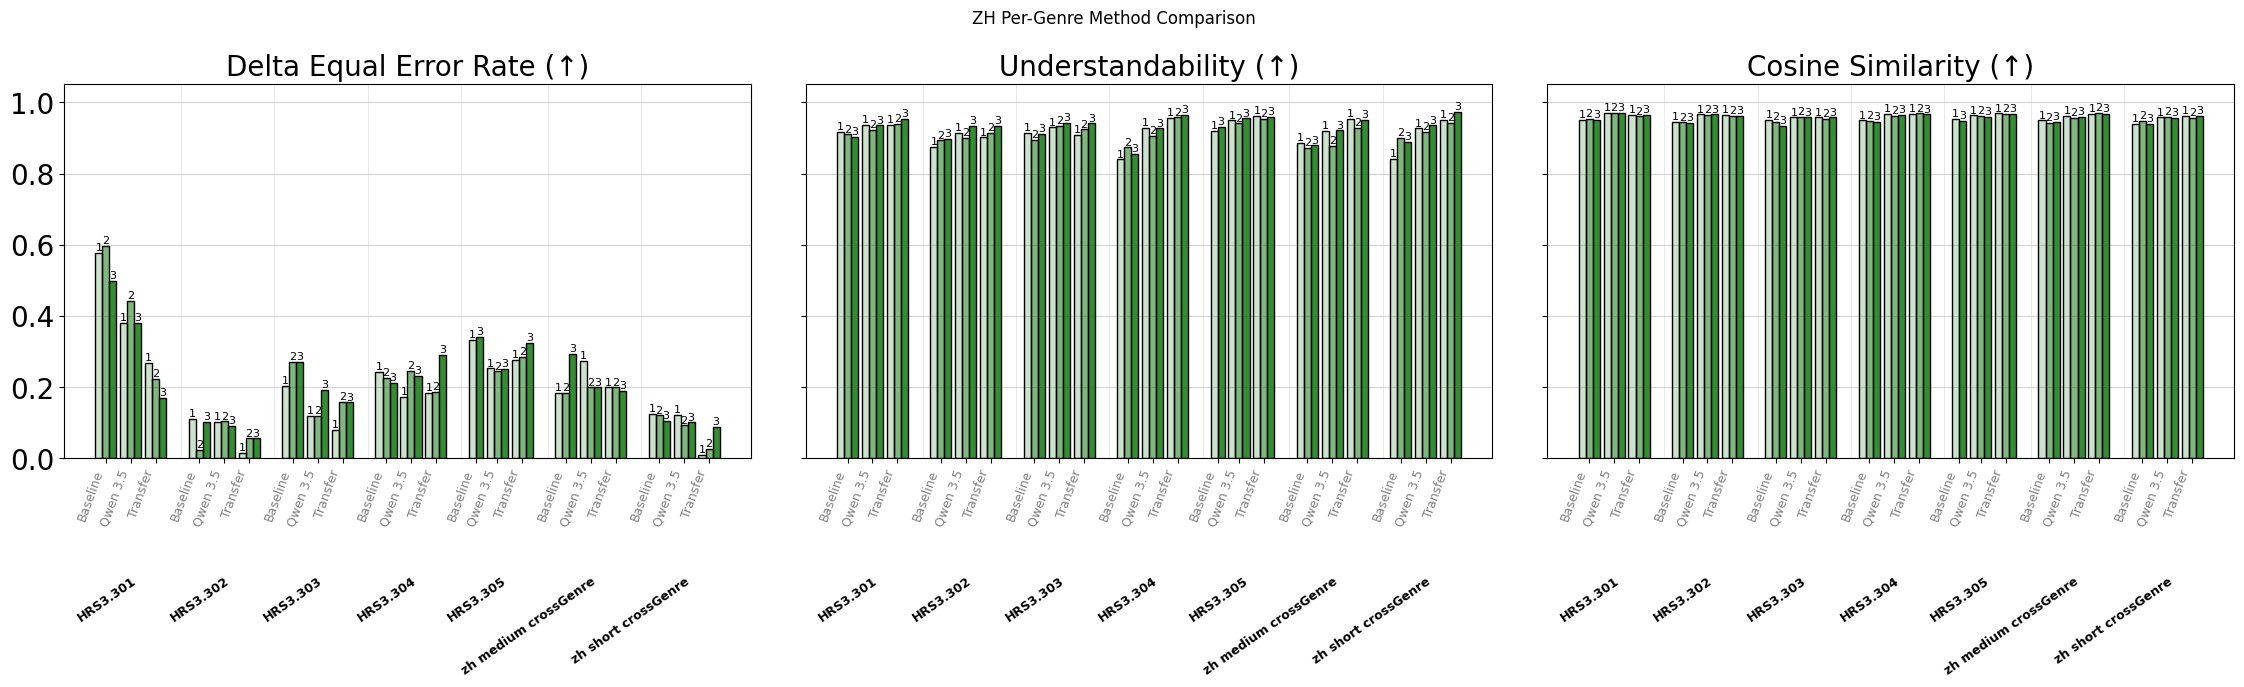

In [215]:
df_plot = filter_plot_df(df_merged)

plot_per_genre_metric_block(
    df=df_plot,
    metrics_path=metrics_path,
    metric_cols=metric_cols,
    nrows=1,
    ncols=3,
    figsize=(28, 6.8),
    output_suffix="per-genre-methods-3",
    tick_rotation=70,
    width=0.22,
    intra_group_gap=0.12,
    genre_gap=0.7,
)

## Per-Genre Tables

In [216]:
def slugify_filename(value):
    value = re.sub(r"[^0-9A-Za-z]+", "-", str(value).strip().lower())
    value = re.sub(r"-{2,}", "-", value).strip("-")
    return value or "table"


def wrap_label(text, width=18, max_lines=3):
    import textwrap

    text = str(text).strip()
    if not text:
        return ""

    wrapped = textwrap.wrap(text, width=width, break_long_words=False, break_on_hyphens=False)
    if len(wrapped) <= max_lines:
        return "\n".join(wrapped)

    trimmed = wrapped[:max_lines]
    last = trimmed[-1]
    if len(last) >= max(4, width - 1):
        last = last[: max(3, width - 1)].rstrip() + "..."
    else:
        last = last + "..."
    trimmed[-1] = last
    return "\n".join(trimmed)


def format_table_column_label(col):
    if isinstance(col, tuple) and len(col) == 3:
        genre, method_label, n_styles = col
        genre_text = format_genre_label(genre) if "format_genre_label" in globals() else str(genre)
        method_text = str(method_label).replace("_", " ")
        style_text = f"styles={n_styles}"
        return "\n".join(
            [
                wrap_label(genre_text, width=16, max_lines=2),
                wrap_label(method_text, width=14, max_lines=2),
                style_text,
            ]
        )

    return wrap_label(str(col), width=18, max_lines=3)


def format_table_row_label(label):
    return wrap_label(str(label), width=26, max_lines=3)


def format_table_value(value):
    if pd.isna(value):
        return ""
    if isinstance(value, (int, float, np.floating, np.integer)):
        return f"{float(value):.4f}"
    return str(value)


def style_pdf_table(table_artist):
    for (row_idx, col_idx), cell in table_artist.get_celld().items():
        cell.set_edgecolor("#D6D6D6")
        cell.set_linewidth(0.35)
        cell.get_text().set_wrap(True)
        cell.get_text().set_rotation(0)

        if row_idx == 0:
            cell.set_facecolor("#F2F2F2")
            cell.get_text().set_fontweight("bold")

        if col_idx == -1:
            cell.set_facecolor("#FBFBFB")
            cell.get_text().set_fontweight("bold")
            cell.get_text().set_ha("left")


def save_rendered_table_pdf(table, pdf_path, title, max_cols_per_page=8):
    from matplotlib.backends.backend_pdf import PdfPages

    pdf_path = Path(pdf_path)
    pdf_path.parent.mkdir(parents=True, exist_ok=True)

    columns = list(table.columns)
    if not columns:
        return

    col_chunks = [columns[i : i + max_cols_per_page] for i in range(0, len(columns), max_cols_per_page)]

    with PdfPages(pdf_path) as pdf:
        total_pages = len(col_chunks)

        for page_idx, cols in enumerate(col_chunks, start=1):
            chunk_df = table.loc[:, cols].copy()
            col_labels = [format_table_column_label(col) for col in chunk_df.columns]
            row_labels = [format_table_row_label(idx) for idx in chunk_df.index]
            cell_text = [[format_table_value(val) for val in row] for row in chunk_df.to_numpy()]

            fig_w = min(28, max(14, 1.55 * len(col_labels) + 3.8))
            fig_h = min(20, max(4.8, 0.72 * len(row_labels) + 2.0))
            fig, ax = plt.subplots(figsize=(fig_w, fig_h))
            ax.axis("off")

            table_artist = ax.table(
                cellText=cell_text,
                colLabels=col_labels,
                rowLabels=row_labels,
                cellLoc="center",
                loc="center",
            )
            table_artist.auto_set_font_size(False)
            table_artist.set_fontsize(8.2)
            table_artist.scale(1.06, 1.45)

            try:
                table_artist.auto_set_column_width(col=list(range(len(col_labels))))
            except Exception:
                pass

            style_pdf_table(table_artist)

            ax.set_title(wrap_label(f"{title} (page {page_idx}/{total_pages})", width=70, max_lines=2), fontsize=11.5, pad=12)
            fig.tight_layout(pad=1.1)
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)


def build_per_genre_metric_table(df_source, metric_cols, metrics_path, language):
    lang_df = df_source[df_source["language"] == language].copy()
    if lang_df.empty:
        return pd.DataFrame()

    method_label_map = {}
    for cfg in metrics_path.values():
        if cfg["language"] != language:
            continue
        exp_id = str(cfg["experiment_id"])
        method_label_map.setdefault(exp_id, cfg.get("xtick_label", cfg["label"]))

    lang_df["method_label"] = lang_df["experiment_id"].map(method_label_map).fillna(lang_df["experiment_id"])

    use_cols = [c for c in metric_cols if c in lang_df.columns]
    if not use_cols:
        return pd.DataFrame()

    index_cols = ["genre", "method_label", "n_styles_to_change"]
    table = (
        lang_df[index_cols + use_cols]
        .set_index(index_cols)
        .sort_index()
        .T
    )

    table.index = [prettify_title(c) for c in table.index]
    return table.round(4)


def display_per_genre_tables(df_source, metric_cols, metrics_path, section_title, output_root=None):
    if df_source.empty:
        print(f"{section_title}: no data available")
        return

    if output_root is None:
        output_root = Path(tables_dir, "per-genre-methods")
    output_root = Path(output_root)
    output_root.mkdir(parents=True, exist_ok=True)

    section_slug = slugify_filename(section_title)
    languages = sorted(df_source["language"].dropna().unique())

    for lang in languages:
        table = build_per_genre_metric_table(df_source, metric_cols, metrics_path, lang)
        if table.empty:
            continue

        stem = f"{section_slug}-{lang.lower()}"
        csv_path = output_root / f"{stem}.csv"
        pdf_path = output_root / f"{stem}.pdf"

        table.to_csv(csv_path)
        save_rendered_table_pdf(table, pdf_path, title=f"{section_title} | {lang.upper()}")

        print(f"\n=== {section_title} | {lang.upper()} ===")
        print(f"Saved CSV: {csv_path}")
        print(f"Saved PDF: {pdf_path}")
        display(table)

In [217]:
# Sense block 1 tables
sense_cols_1 = list(metrics.keys())[:6]
df_sense_1 = build_per_genre_mean_metrics_df(metrics_path, sense_cols_1)
display_per_genre_tables(filter_plot_df(df_sense_1), sense_cols_1, metrics_path, "Sense Scores 1-6")

# Sense block 2 tables
sense_cols_2 = list(metrics.keys())[6:12]
df_sense_2 = build_per_genre_mean_metrics_df(metrics_path, sense_cols_2)
display_per_genre_tables(filter_plot_df(df_sense_2), sense_cols_2, metrics_path, "Sense Scores 7-12")

# Privacy + remaining sense tables
sense_cols_3 = list(metrics.keys())[12:14]
df_sense_3 = build_per_genre_mean_metrics_df(metrics_path, sense_cols_3)
df_priv_3 = build_per_genre_privacy_df(metrics_path, metric_name="delta_equal_error_rate")
merge_keys = ["language", "genre", "experiment_id", "model_label", "n_styles_to_change"]
df_table_3 = df_sense_3.merge(df_priv_3, on=merge_keys, how="outer")
metric_cols_3 = ["delta_equal_error_rate"] + sense_cols_3
display_per_genre_tables(filter_plot_df(df_table_3), metric_cols_3, metrics_path, "Privacy + Remaining Sense")


=== Sense Scores 1-6 | AR ===
Saved CSV: /gscratch/ifml1/kogolobo/tables/per-genre-methods/sense-scores-1-6-ar.csv
Saved PDF: /gscratch/ifml1/kogolobo/tables/per-genre-methods/sense-scores-1-6-ar.pdf


genre                    AMINA                                           \
method_label          Qwen 2.5                 Qwen 3.5                   
n_styles_to_change           1       2       3        1       2       3   
Semantic Coverage (↑)   0.9029  0.8918  0.8884   0.8994  0.9010  0.9002   
Factuality (↑)          0.9508  0.9422  0.9390   0.9405  0.9447  0.9471   
Informativeness (↑)     0.9074  0.8964  0.8873   0.8964  0.8958  0.8958   
Relevance (↑)           0.9878  0.9776  0.9709   0.9802  0.9793  0.9810   
Specificity (↑)         0.9144  0.9013  0.8894   0.8971  0.8918  0.8985   
Correctness (↑)         0.9511  0.9416  0.9397   0.9371  0.9443  0.9466   

genre                 ar_twitter_1                           ...  \
method_label              Baseline                 Qwen 2.5  ...   
n_styles_to_change               1       2       3        1  ...   
Semantic Coverage (↑)       0.6545  0.5526  0.4532   0.8513  ...   
Factuality (↑)              0.6727  0.5766  0.4974   0.8805  ...   
Informativeness (↑)         0.6494  0.5442  0.4545   0.8519  ...   
Relevance (↑)               0.7636  0.6435  0.5416   0.9545  ...   
Specificity (↑)             0.5773  0.5078  0.4058   0.7890  ...   
Correctness (↑)             0.7279  0.6110  0.5455   0.9273  ...   

genre                 bbn_aljazeera_blog_1 saudinewsnet                  \
method_label                      Qwen 3.5     Baseline                   
n_styles_to_change                       3            1       2       3   
Semantic Coverage (↑)               0.8964       0.6473  0.5554  0.5712   
Factuality (↑)                      0.9422       0.6975  0.6050  0.6360   
Informativeness (↑)                 0.8882       0.6358  0.5458  0.5633   
Relevance (↑)                       0.9728       0.7783  0.6960  0.7269   
Specificity (↑)                     0.8814       0.5896  0.5021  0.5188   
Correctness (↑)                     0.9365       0.7144  0.6192  0.6656   

genre                                                                    
method_label          Qwen 2.5                 Qwen 3.5                  
n_styles_to_change           1       2       3        1       2       3  
Semantic Coverage (↑)   0.8942  0.8841  0.8781   0.8972  0.8976  0.8957  
Factuality (↑)          0.9412  0.9337  0.9313   0.9468  0.9444  0.9479  
Informativeness (↑)     0.8931  0.8824  0.8719   0.8966  0.8908  0.8908  
Relevance (↑)           0.9736  0.9597  0.9536   0.9760  0.9753  0.9730  
Specificity (↑)         0.8927  0.8796  0.8702   0.8972  0.8876  0.8764  
Correctness (↑)         0.9406  0.9236  0.9185   0.9416  0.9361  0.9423  

[6 rows x 30 columns]


=== Sense Scores 1-6 | EN ===
Saved CSV: /gscratch/ifml1/kogolobo/tables/per-genre-methods/sense-scores-1-6-en.csv
Saved PDF: /gscratch/ifml1/kogolobo/tables/per-genre-methods/sense-scores-1-6-en.pdf


genre                 en_crossGenre                                           \
method_label               Baseline                 Qwen 3.5                   
n_styles_to_change                1       2       3        1       2       3   
Semantic Coverage (↑)        0.9082  0.8754  0.8799   0.9104  0.8687  0.8664   
Factuality (↑)               0.9627  0.9104  0.9224   0.9813  0.9612  0.9545   
Informativeness (↑)          0.9164  0.8642  0.8724   0.9269  0.8776  0.8739   
Relevance (↑)                0.9933  0.9739  0.9746   0.9978  0.9746  0.9746   
Specificity (↑)              0.8701  0.8015  0.8179   0.8925  0.8366  0.8231   
Correctness (↑)              0.9694  0.9030  0.9104   0.9828  0.9515  0.9403   

genre                 en_short_crossGenre                           ...  \
method_label                     Baseline                 Qwen 3.5  ...   
n_styles_to_change                      1       2       3        1  ...   
Semantic Coverage (↑)              0.8689  0.8580  0.8492   0.8967  ...   
Factuality (↑)                     0.9362  0.9075  0.9042   0.9787  ...   
Informativeness (↑)                0.8858  0.8525  0.8454   0.9075  ...   
Relevance (↑)                      0.9712  0.9604  0.9575   0.9812  ...   
Specificity (↑)                    0.8104  0.7812  0.7796   0.8704  ...   
Correctness (↑)                    0.9438  0.9188  0.9142   0.9579  ...   

genre                 perGenre-HRS3.4                           \
method_label                 Baseline Qwen 3.5                   
n_styles_to_change                  3        1       2       3   
Semantic Coverage (↑)          0.8585   0.9109  0.8785  0.8613   
Factuality (↑)                 0.9180   0.9827  0.9563  0.9342   
Informativeness (↑)            0.8651   0.9222  0.8827  0.8549   
Relevance (↑)                  0.9574   0.9845  0.9757  0.9669   
Specificity (↑)                0.7831   0.8817  0.8264  0.7771   
Correctness (↑)                0.9327   0.9651  0.9356  0.9183   

genre                 perGenre-HRS3.5                                           
method_label                 Baseline                 Qwen 3.5                  
n_styles_to_change                  1       2       3        1       2       3  
Semantic Coverage (↑)          0.8873  0.8724  0.8802   0.8994  0.8698  0.8620  
Factuality (↑)                 0.9269  0.9227  0.9279   0.9773  0.9464  0.9367  
Informativeness (↑)            0.8808  0.8666  0.8756   0.9023  0.8604  0.8519  
Relevance (↑)                  0.9808  0.9779  0.9828   0.9844  0.9734  0.9662  
Specificity (↑)                0.8425  0.8442  0.8536   0.9019  0.8429  0.8256  
Correctness (↑)                0.9464  0.9315  0.9377   0.9705  0.9318  0.9195  

[6 rows x 42 columns]


=== Sense Scores 1-6 | RU ===
Saved CSV: /gscratch/ifml1/kogolobo/tables/per-genre-methods/sense-scores-1-6-ru.csv
Saved PDF: /gscratch/ifml1/kogolobo/tables/per-genre-methods/sense-scores-1-6-ru.pdf


...

genre                      en_crossGenre                                   \
method_label                    Baseline                 Qwen 3.5           
n_styles_to_change                     1       2       3        1       2   
Delta Equal Error Rate (↑)        0.3229  0.4461  0.4154   0.1692  0.2308   
Understandability (↑)             0.9485  0.8993  0.9082   0.9515  0.8560   
Cosine Similarity (↑)             0.9415  0.9310  0.9333   0.9534  0.9480   

genre                              en_short_crossGenre                  \
method_label                                  Baseline                   
n_styles_to_change               3                   1       2       3   
Delta Equal Error Rate (↑)  0.2923              0.2040  0.1896  0.1665   
Understandability (↑)       0.8396              0.9058  0.8629  0.8750   
Cosine Similarity (↑)       0.9427              0.9354  0.9267  0.9215   

genre                                ... perGenre-HRS3.4                   \
method_label               Qwen 3.5  ...        Baseline Qwen 3.5           
n_styles_to_change                1  ...               3        1       2   
Delta Equal Error Rate (↑)   0.1826  ...          0.3125   0.1938  0.3100   
Understandability (↑)        0.9075  ...          0.8789   0.9401  0.8718   
Cosine Similarity (↑)        0.9484  ...          0.9262   0.9482  0.9306   

genre                              perGenre-HRS3.5                           \
method_label                              Baseline                 Qwen 3.5   
n_styles_to_change               3               1       2       3        1   
Delta Equal Error Rate (↑)  0.3185          0.2531  0.2286  0.2525   0.2806   
Understandability (↑)       0.8370          0.9175  0.8929  0.9084   0.9195   
Cosine Similarity (↑)       0.9264          0.9403  0.9361  0.9372   0.9510   

genre                                       
method_label                                
n_styles_to_change               2       3  
Delta Equal Error Rate (↑)  0.2590  0.2857  
Understandability (↑)       0.8640  0.8276  
Cosine Similarity (↑)       0.9447  0.9373  

[3 rows x 42 columns]


=== Privacy + Remaining Sense | RU ===
Saved CSV: /gscratch/ifml1/kogolobo/tables/per-genre-methods/privacy-remaining-sense-ru.csv
Saved PDF: /gscratch/ifml1/kogolobo/tables/per-genre-methods/privacy-remaining-sense-ru.pdf


genre                      perGenre-HRS2.101                                   \
method_label                        Baseline                 Qwen 3.5           
n_styles_to_change                         1       2       3        1       2   
Delta Equal Error Rate (↑)            0.1853  0.1853  0.1754   0.1857  0.2766   
Understandability (↑)                 0.9431  0.9246  0.9015   0.8831  0.8538   
Cosine Similarity (↑)                 0.9518  0.9477  0.9470   0.9551  0.9519   

genre                              perGenre-HRS2.102                           \
method_label                                Baseline                 Qwen 3.5   
n_styles_to_change               3                 1       2       3        1   
Delta Equal Error Rate (↑)  0.2311            0.2205  0.2216  0.1888   0.1818   
Understandability (↑)       0.8408            0.9029  0.8596  0.8713   0.9081   
Cosine Similarity (↑)       0.9496            0.9654  0.9558  0.9562   0.9681   

genre                       ... perGenre-HRS2.105                           \
method_label                ...          Baseline Qwen 3.5                   
n_styles_to_change          ...                 3        1       2       3   
Delta Equal Error Rate (↑)  ...            0.3359   0.2524  0.3297  0.3367   
Understandability (↑)       ...            0.9122   0.9041  0.8649  0.8541   
Cosine Similarity (↑)       ...            0.9527   0.9594  0.9520  0.9497   

genre                      ru_crossGenre                                   \
method_label                    Baseline                 Qwen 3.5           
n_styles_to_change                     1       2       3        1       2   
Delta Equal Error Rate (↑)        0.2885  0.3077  0.3077   0.2692  0.2838   
Understandability (↑)             0.9100  0.8913  0.9040   0.9053  0.8747   
Cosine Similarity (↑)             0.9551  0.9504  0.9491   0.9591  0.9535   

genre                               
method_label                        
n_styles_to_change               3  
Delta Equal Error Rate (↑)  0.3077  
Understandability (↑)       0.8453  
Cosine Similarity (↑)       0.9500  

[3 rows x 36 columns]


=== Privacy + Remaining Sense | ZH ===
Saved CSV: /gscratch/ifml1/kogolobo/tables/per-genre-methods/privacy-remaining-sense-zh.csv
Saved PDF: /gscratch/ifml1/kogolobo/tables/per-genre-methods/privacy-remaining-sense-zh.pdf


genre                      perGenre-HRS3.301                                   \
method_label                        Baseline                 Qwen 3.5           
n_styles_to_change                         1       2       3        1       2   
Delta Equal Error Rate (↑)            0.5770  0.5980  0.4989   0.3812  0.4434   
Understandability (↑)                 0.9171  0.9100  0.9029   0.9360  0.9228   
Cosine Similarity (↑)                 0.9504  0.9539  0.9515   0.9699  0.9697   

genre                                                       perGenre-HRS3.302  \
method_label                       Transfer                          Baseline   
n_styles_to_change               3        1       2       3                 1   
Delta Equal Error Rate (↑)  0.3812   0.2682  0.2233  0.1707            0.1123   
Understandability (↑)       0.9351   0.9360  0.9386  0.9544            0.8750   
Cosine Similarity (↑)       0.9710   0.9641  0.9608  0.9639            0.9453   

genre                       ... zh_medium_crossGenre zh_short_crossGenre  \
method_label                ...             Transfer            Baseline   
n_styles_to_change          ...                    3                   1   
Delta Equal Error Rate (↑)  ...               0.1902              0.1251   
Understandability (↑)       ...               0.9514              0.8414   
Cosine Similarity (↑)       ...               0.9682              0.9403   

genre                                                                         \
method_label                               Qwen 3.5                 Transfer   
n_styles_to_change               2       3        1       2       3        1   
Delta Equal Error Rate (↑)  0.1213  0.1048   0.1232  0.0927  0.1014   0.0105   
Understandability (↑)       0.9000  0.8886   0.9265  0.9173  0.9357   0.9510   
Cosine Similarity (↑)       0.9486  0.9392   0.9578  0.9592  0.9563   0.9617   

genre                                       
method_label                                
n_styles_to_change               2       3  
Delta Equal Error Rate (↑)  0.0264  0.0880  
Understandability (↑)       0.9429  0.9724  
Cosine Similarity (↑)       0.9569  0.9627  

[3 rows x 62 columns]